<div style="background:#F0F4FA; border-left:5px solid #1F4E79; border-radius:6px; padding:18px 22px; margin-bottom:8px; font-family:Arial,sans-serif;">
  <h2 style="color:#1F4E79; margin:0 0 6px 0; font-size:16pt;">Mapping the Cancer Research Attention Gap Using Unsupervised Learning</h2>
  <p style="margin:2px 0; font-size:11pt; color:#333;"><b>Course:</b> APANPS5205: Applied Analytics Frameworks and Methods II</p>
  <p style="margin:2px 0; font-size:11pt; color:#333;"><b>Group:</b> Group 2</p>
  <p style="margin:2px 0; font-size:11pt; color:#333;"><b>Notebook:</b> 02_WORKING_ANALYSIS_ALL_ATTEMPTS.ipynb</p>
  <p style="margin:10px 0 2px 0; font-size:11pt; color:#333;"><b>Purpose:</b></p>
  <p style="margin:2px 0; font-size:11pt; color:#333;">
    This is the <b>working analysis notebook</b> for the project. It documents every analytical approach
    that was tested while investigating the core research question:
    <b><i>Are cancer research resources aligned with the burden of disease?</i></b>
    It includes metric-construction attempts, exploratory charts, clustering experiments, and an optional
    NLP/topic-modeling exploration. The analytical design was refined based on proposal-stage feedback,
    and methods that were tried but ultimately not carried into the final report are documented below,
    along with the reasoning for excluding them.
  </p>
</div>


<div style="background:#FAFAFA; border:1px solid #D0D0D0; border-radius:6px; padding:14px 18px; margin-bottom:10px; font-family:Arial,sans-serif; font-size:11pt;">
<b>At a Glance</b>

| | |
|---|---|
| **Dataset** | 80 cancer-year observations |
| **Cancer types** | 16 |
| **Years covered** | 2019–2023 |
| **Main unit of analysis** | Cancer type |
| **Primary metric** | Composite Attention Gap Score |
| **Supporting methods** | K-means clustering, TF-IDF / NMF topic modeling (if text is sufficient) |
| **Final use** | Working notebook; the final report uses only the selected results documented in Section 10 |

</div>


<p style="font-size:15px;"><b><u>1. Project Setup</u></b></p>

This section mounts Google Drive, defines every folder used by the project, creates any folders that
do not yet exist, and imports the libraries needed for this notebook. The analysis relies mainly on
`pandas`, `numpy`, `matplotlib`, and `scikit-learn`; `seaborn` is intentionally avoided so that all
charts share one consistent matplotlib style.


In [ ]:
# ============================================================
# Project setup
# ============================================================

from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------
try:
    drive.mount("/content/drive", force_remount=True)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
except ValueError:
    drive.mount("/content/gdrive", force_remount=True)
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")

print("Google Drive mounted at:", DRIVE_ROOT)

# ------------------------------------------------------------
# 2. Locate the project folder
# ------------------------------------------------------------
PROJECT_FOLDER_NAME = "Cancer_Research_Attention_Gap_Final"
PROJECT_DIR = DRIVE_ROOT / PROJECT_FOLDER_NAME

if not PROJECT_DIR.exists():
    print("Project folder not found directly in My Drive. Searching...")
    matches = list(DRIVE_ROOT.rglob(PROJECT_FOLDER_NAME))
    if matches:
        PROJECT_DIR = matches[0]
        print("Project folder found at:", PROJECT_DIR)
    else:
        raise FileNotFoundError(
            f"Could not find '{PROJECT_FOLDER_NAME}' in Google Drive.\n"
            "Add the shared folder as a shortcut to My Drive, or update PROJECT_DIR manually."
        )

# ------------------------------------------------------------
# 3. Define project subfolders (matching the required folder structure)
# ------------------------------------------------------------
DATA_DIR           = PROJECT_DIR / "01 Data"
RAW_DIR             = DATA_DIR / "Raw Data"
CLEAN_DIR           = DATA_DIR / "Cleaned Data"
PROCESSED_DIR       = DATA_DIR / "Processed Analysis Data"

WORKING_CODE_DIR    = PROJECT_DIR / "02 Working Python Code"
FINAL_CODE_DIR      = PROJECT_DIR / "03 Final Python Code"

OUTPUT_DIR          = PROJECT_DIR / "04 Output Files"
CHART_DIR           = OUTPUT_DIR / "Charts"
TABLE_DIR           = OUTPUT_DIR / "Tables"

REPORT_DIR          = PROJECT_DIR / "05 Final Report"
PRESENTATION_DIR    = PROJECT_DIR / "06 Presentation"

ALL_FOLDERS = [
    PROJECT_DIR, DATA_DIR, RAW_DIR, CLEAN_DIR, PROCESSED_DIR,
    WORKING_CODE_DIR, FINAL_CODE_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR,
    REPORT_DIR, PRESENTATION_DIR,
]

for folder in ALL_FOLDERS:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 4. Display settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ------------------------------------------------------------
# 5. Confirmation
# ------------------------------------------------------------
print("\nProject setup complete.")
for name, path in [
    ("PROJECT_DIR", PROJECT_DIR), ("CLEAN_DIR", CLEAN_DIR),
    ("PROCESSED_DIR", PROCESSED_DIR), ("CHART_DIR", CHART_DIR),
    ("TABLE_DIR", TABLE_DIR),
]:
    print(f"{name}: {path}")


Mounted at /content/drive
Google Drive mounted at: /content/drive/MyDrive
Project folder not found directly in My Drive. Searching...
Project folder found at: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final

Project setup complete.
PROJECT_DIR: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final
CLEAN_DIR: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Cleaned Data
PROCESSED_DIR: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data
CHART_DIR: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts
TABLE_DIR: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables


<p style="font-size:15px;"><b><u>2. Load Cleaned Dataset</u></b></p>

Loads `cancer_attention_gap_clean.csv` from `CLEAN_DIR` and runs a set of basic sanity checks
(file existence, shape, columns, dtypes, year range, cancer types, and missing values) before any
analysis is attempted.


In [ ]:
# ============================================================
# Load cleaned dataset
# ============================================================

clean_file = CLEAN_DIR / "cancer_attention_gap_clean.csv"

if not clean_file.exists():
    raise FileNotFoundError(f"Cleaned data file not found at: {clean_file}")

df = pd.read_csv(clean_file)

print("File loaded:", clean_file)
print("Shape (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nYears included:", sorted(df["year"].unique().tolist()))
print("\nCancer types included (n =", df["cancer_type"].nunique(), "):")
print(sorted(df["cancer_type"].unique().tolist()))

print("\nMissing value summary (columns with at least 1 missing value):")
missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print(missing_summary if len(missing_summary) else "No missing values found.")


File loaded: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Cleaned Data/cancer_attention_gap_clean.csv
Shape (rows, columns): (80, 23)

Column names:
['cancer_type', 'year', 'incidence_rate', 'incidence_value_source', 'mortality_rate', 'five_year_survival_rate', 'survival_value_source', 'source', 'source_url', 'trial_count', 'active_trial_count', 'phase_1_count', 'phase_2_count', 'phase_3_count', 'trial_text_sample', 'publication_count', 'publication_text_sample', 'publication_title_sample', 'journal_sample', 'trial_to_mortality_ratio', 'publication_to_mortality_ratio', 'attention_gap_score', 'combined_text_sample']

First 5 rows:


,cancer_type,year,incidence_rate,incidence_value_source,mortality_rate,five_year_survival_rate,survival_value_source,source,source_url,trial_count,active_trial_count,phase_1_count,phase_2_count,phase_3_count,trial_text_sample,publication_count,publication_text_sample,publication_title_sample,journal_sample,trial_to_mortality_ratio,publication_to_mortality_ratio,attention_gap_score,combined_text_sample
0,Breast Cancer,2019,135.690,SEER 12 observed,19.750,93.300,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,12,4,0,3,2,Breast cancer patients who received docetaxel ...,19987,Early breast cancer: ESMO Clinical Practice Gu...,Early breast cancer: ESMO Clinical Practice Gu...,Annals of oncology : official journal of the E...,0.608,"1,012.000",0.378,Breast cancer patients who received docetaxel ...
1,Breast Cancer,2020,122.100,SEER 12 observed,19.450,93.440,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,20,4,4,7,0,"Recently, there is growing interest in the app...",22807,"Breast cancer: Biology, biomarkers, and treatm...","Breast cancer: Biology, biomarkers, and treatm...",International immunopharmacology | Cancer cell...,1.028,"1,172.596",0.047,"Recently, there is growing interest in the app..."
2,Breast Cancer,2021,139.390,SEER 12 observed,19.220,93.560,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,17,6,3,2,1,The purpose of this study is to investigate th...,24442,Breast Surgery: Management of Postoperative Co...,Breast Surgery: Management of Postoperative Co...,The Surgical clinics of North America | Annals...,0.884,"1,271.696",0.119,The purpose of this study is to investigate th...
3,Breast Cancer,2022,136.080,SEER 12 observed,18.860,93.690,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,18,6,5,5,0,"In this study, a randomized controlled study w...",24185,"Breast cancer: presentation, investigation and...","Breast cancer: presentation, investigation and...","British journal of hospital medicine (London, ...",0.954,"1,282.344",0.041,"In this study, a randomized controlled study w..."
4,Breast Cancer,2023,136.500,SEER 12 observed,18.500,93.810,Modeled trend,SEER Cancer Stat Facts,https://seer.cancer.gov/statfacts/html/breast....,14,7,4,0,3,"This is a multicentre, multinational Phase Ib ...",23873,Molecular Classification of Breast Cancer. Bre...,Molecular Classification of Breast Cancer. | E...,PET clinics | Annals of oncology : official jo...,0.757,"1,290.432",0.162,"This is a multicentre, multinational Phase Ib ..."



Data types:
cancer_type                        object
year                                int64
incidence_rate                    float64
incidence_value_source             object
mortality_rate                    float64
five_year_survival_rate           float64
survival_value_source              object
source                             object
source_url                         object
trial_count                         int64
active_trial_count                  int64
phase_1_count                       int64
phase_2_count                       int64
phase_3_count                       int64
trial_text_sample                  object
publication_count                   int64
publication_text_sample            object
publication_title_sample           object
journal_sample                     object
trial_to_mortality_ratio          float64
publication_to_mortality_ratio    float64
attention_gap_score               float64
combined_text_sample               object
dtype: object

Years 

<p style="font-size:15px;"><b><u>3. Initial Exploratory Data Review</u></b></p>

Quick, concise EDA on the raw cancer-year level data (80 rows = 16 cancer types x 5 years). This
step confirms the data is well-formed before it is aggregated to the cancer level in Section 4.


In [ ]:
# ============================================================
# Numeric summary statistics
# ============================================================

key_numeric_cols = [
    "incidence_rate", "mortality_rate", "five_year_survival_rate",
    "trial_count", "active_trial_count",
    "phase_1_count", "phase_2_count", "phase_3_count",
    "publication_count",
]
key_numeric_cols = [c for c in key_numeric_cols if c in df.columns]

print("Summary statistics for key numeric variables:")
display(df[key_numeric_cols].describe().T)

print("\nMissing values for key variables:")
print(df[key_numeric_cols].isna().sum())

print("\nCancer type row counts (should be 5 rows each, one per year):")
print(df["cancer_type"].value_counts())

print("\nYear range:", df["year"].min(), "-", df["year"].max())


Summary statistics for key numeric variables:


,count,mean,std,min,25%,50%,75%,max
incidence_rate,80.000,29.897,37.972,2.260,9.532,14.450,26.852,139.390
mortality_rate,80.000,8.416,8.290,0.250,3.248,5.340,11.680,34.150
five_year_survival_rate,80.000,66.664,27.287,15.680,40.278,72.910,92.895,99.300
trial_count,80.000,16.512,4.481,8.000,13.000,17.000,20.000,29.000
active_trial_count,80.000,5.925,3.097,1.000,4.000,6.000,8.000,13.000
phase_1_count,80.000,4.562,2.474,0.000,3.000,4.000,6.000,11.000
phase_2_count,80.000,5.237,2.706,0.000,3.000,6.000,7.000,11.000
phase_3_count,80.000,0.912,1.058,0.000,0.000,1.000,1.000,5.000
publication_count,80.000,"6,189.837","6,301.103",181.000,"1,348.500","3,580.000","9,746.250","24,442.000"



Missing values for key variables:
incidence_rate             0
mortality_rate             0
five_year_survival_rate    0
trial_count                0
active_trial_count         0
phase_1_count              0
phase_2_count              0
phase_3_count              0
publication_count          0
dtype: int64

Cancer type row counts (should be 5 rows each, one per year):
cancer_type
Breast Cancer           5
Lung Cancer             5
Colorectal Cancer       5
Pancreatic Cancer       5
Prostate Cancer         5
Ovarian Cancer          5
Liver Cancer            5
Brain Cancer            5
Leukemia                5
Melanoma                5
Bladder Cancer          5
Kidney Cancer           5
Stomach Cancer          5
Thyroid Cancer          5
Hodgkin Lymphoma        5
Non-Hodgkin Lymphoma    5
Name: count, dtype: int64

Year range: 2019 - 2023


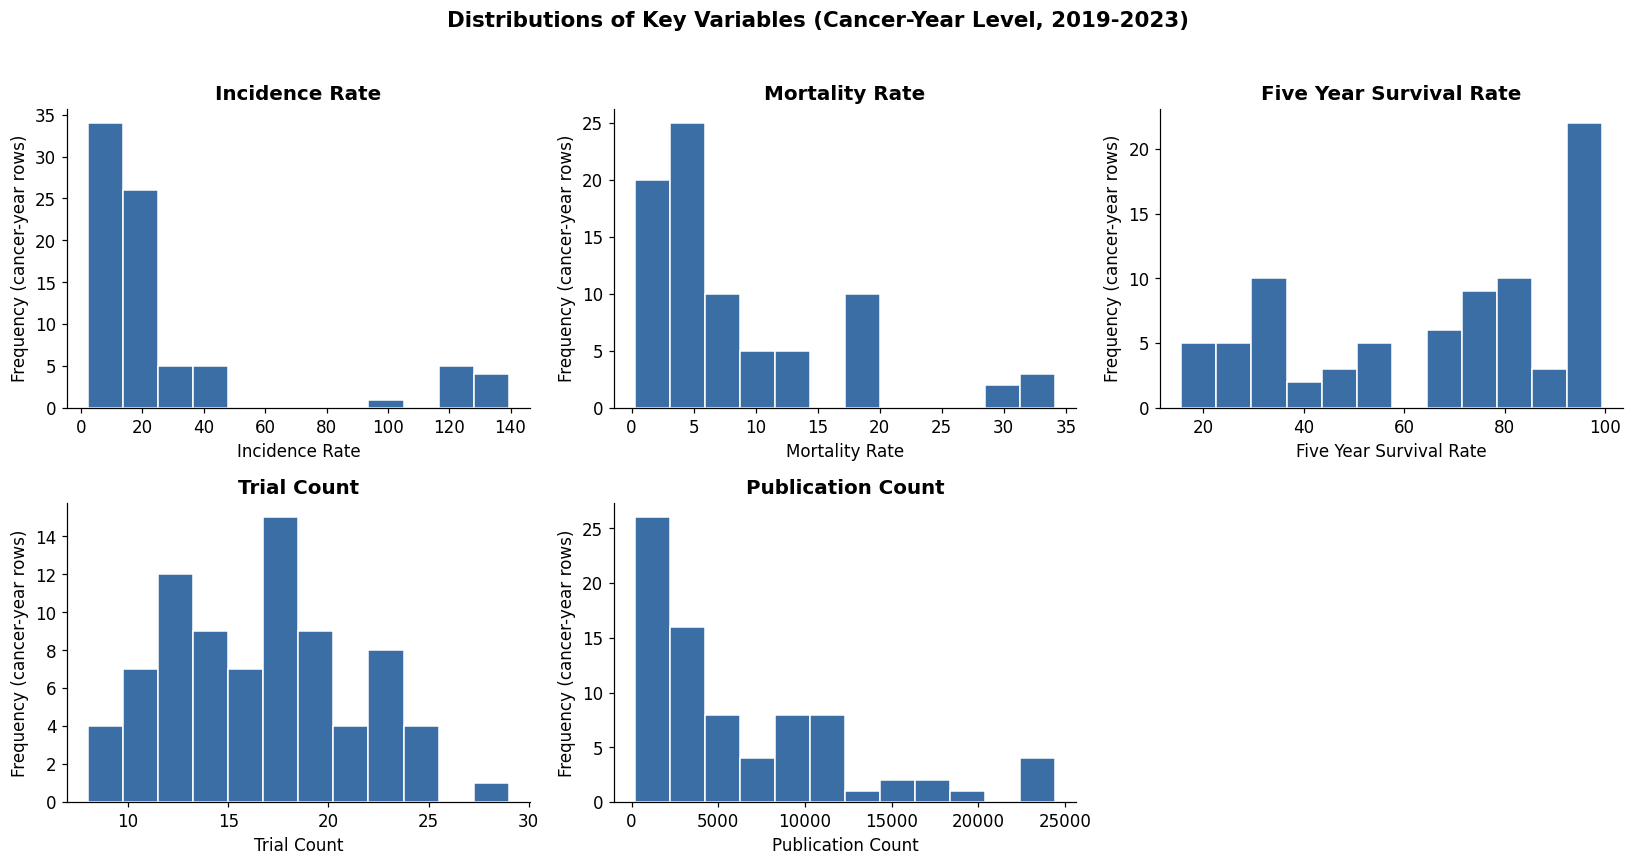

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/01_eda_key_variable_distributions.png


In [ ]:
# ============================================================
# Distributions of key variables (saved to CHART_DIR)
# ============================================================

dist_vars = ["incidence_rate", "mortality_rate", "five_year_survival_rate",
             "trial_count", "publication_count"]
dist_vars = [v for v in dist_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(dist_vars):
    axes[i].hist(df[col], bins=12, color="#3B6EA5", edgecolor="white")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Frequency (cancer-year rows)")

# Hide any unused subplot
for j in range(len(dist_vars), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distributions of Key Variables (Cancer-Year Level, 2019-2023)", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

eda_chart_path = CHART_DIR / "01_eda_key_variable_distributions.png"
fig.savefig(eda_chart_path, bbox_inches="tight")
plt.show()

print("Saved:", eda_chart_path)


<p style="font-size:15px;"><b><u>4. Cancer-Level Aggregation</u></b></p>

The cleaned dataset has one row per cancer type per year (80 rows total). To answer the core
question — whether research attention matches disease burden — the data is aggregated to
**one row per cancer type (16 rows)**, averaging rate-based variables across 2019-2023 and
summing count-based variables. This produces `analysis_df`, the base table used for every
metric, chart, and clustering attempt below.


In [ ]:
# ============================================================
# Aggregate to one row per cancer type
# ============================================================

# Text columns are included only if present in the source file
optional_text_cols = ["trial_text_sample", "publication_text_sample", "combined_text_sample"]
available_text_cols = [c for c in optional_text_cols if c in df.columns]


def first_non_null_text(series):
    """Return the first non-null text sample for a group, or an empty string."""
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else ""


agg_dict = {
    "incidence_rate": "mean",
    "mortality_rate": "mean",
    "five_year_survival_rate": "mean",
    "trial_count": "sum",
    "active_trial_count": "sum",
    "publication_count": "sum",
    "phase_1_count": "sum",
    "phase_2_count": "sum",
    "phase_3_count": "sum",
}
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

analysis_df = df.groupby("cancer_type").agg(agg_dict).reset_index()

# Rename to the required column names
rename_map = {
    "incidence_rate": "avg_incidence_rate",
    "mortality_rate": "avg_mortality_rate",
    "five_year_survival_rate": "avg_five_year_survival_rate",
    "trial_count": "total_trial_count",
    "active_trial_count": "total_active_trial_count",
    "publication_count": "total_publication_count",
    "phase_1_count": "total_phase_1_count",
    "phase_2_count": "total_phase_2_count",
    "phase_3_count": "total_phase_3_count",
}
analysis_df = analysis_df.rename(columns=rename_map)

# Attach one representative text sample per cancer type (if text columns exist)
for col in available_text_cols:
    sample_col_name = col.replace("_text_sample", "_text_sample")  # keep original name
    text_samples = df.groupby("cancer_type")[col].apply(first_non_null_text).reset_index()
    analysis_df = analysis_df.merge(text_samples, on="cancer_type", how="left")

print("analysis_df shape:", analysis_df.shape)
display(analysis_df.head(16))


analysis_df shape: (16, 13)


,cancer_type,avg_incidence_rate,avg_mortality_rate,avg_five_year_survival_rate,total_trial_count,total_active_trial_count,total_publication_count,total_phase_1_count,total_phase_2_count,total_phase_3_count,trial_text_sample,publication_text_sample,combined_text_sample
0,Bladder Cancer,17.054,4.140,80.020,97,34,15866,23,26,9,Bladder cancer is the most common urinary trac...,The global burden of urinary bladder cancer: a...,Bladder cancer is the most common urinary trac...
1,Brain Cancer,5.848,4.398,34.740,71,24,2383,14,18,4,The purpose of research is to study to adverse...,Tumor-Derived Extracellular Vesicles Breach th...,The purpose of research is to study to adverse...
2,Breast Cancer,133.952,19.156,93.560,81,27,115294,16,17,6,Breast cancer patients who received docetaxel ...,Early breast cancer: ESMO Clinical Practice Gu...,Breast cancer patients who received docetaxel ...
3,Colorectal Cancer,35.224,12.858,68.168,82,22,55062,17,24,3,The purpose of this study is to evaluate the s...,Colorectal Cancer and Nutrition. Colorectal Ca...,The purpose of this study is to evaluate the s...
4,Hodgkin Lymphoma,2.400,0.256,92.314,75,32,7802,33,31,10,"This is an open-label, single-group, Phase I/I...",Diagnosis of Hodgkin lymphoma in the modern er...,"This is an open-label, single-group, Phase I/I..."
5,Kidney Cancer,15.648,3.440,81.890,77,32,3159,18,17,2,The purpose of this study is to evaluate the s...,The Metabolic Basis of Kidney Cancer. Kidney c...,The purpose of this study is to evaluate the s...
6,Leukemia,14.064,5.844,72.166,88,44,51522,35,39,6,A phase II study testing the efficacy of combi...,A Menin-MLL Inhibitor Induces Specific Chromat...,A phase II study testing the efficacy of combi...
7,Liver Cancer,8.942,6.622,23.732,87,29,14897,17,32,8,The purpose of this study is to evaluate the e...,Tumor Cell Biodiversity Drives Microenvironmen...,The purpose of this study is to evaluate the e...
8,Lung Cancer,40.012,31.538,34.478,92,29,79441,27,36,4,"A phase 1/2, first-in-human, open-label study ...",Lung Cancer. Lung cancer is the world's leadin...,"A phase 1/2, first-in-human, open-label study ..."
9,Melanoma,24.014,2.020,96.558,80,35,38542,36,32,1,"BERING-MELANOMA - designed as a prospective, l...",Current state of melanoma diagnosis and treatm...,"BERING-MELANOMA - designed as a prospective, l..."


In [ ]:
# ============================================================
# Save the cancer-level base table
# ============================================================

base_output_path = PROCESSED_DIR / "cancer_attention_gap_analysis_base.csv"
analysis_df.to_csv(base_output_path, index=False)
print("Saved:", base_output_path)


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data/cancer_attention_gap_analysis_base.csv


<p style="font-size:15px;"><b><u>5. Attention Gap Metric Development</u></b></p>

To make the research question measurable, this section develops a specific **Attention Gap Score**.
Rather than settling on one formula immediately, several candidate metrics are computed and compared
side by side so the strongest one can be chosen for the final report.

- **Attempt 1:** Publication-to-Mortality Ratio
- **Attempt 2:** Trial-to-Mortality Ratio
- **Attempt 3:** Publication-to-Incidence Ratio
- **Attempt 4:** Trial-to-Incidence Ratio
- **Attempt 5:** Composite Attention Gap Score (percentile-rank based burden score vs. research
  attention score) — this is the metric carried forward into clustering and the final report.


In [ ]:
# ============================================================
# Attempts 1-4: simple ratio-based metrics
# ============================================================

analysis_df["publication_to_mortality_ratio"] = (
    analysis_df["total_publication_count"] / analysis_df["avg_mortality_rate"]
)
analysis_df["trial_to_mortality_ratio"] = (
    analysis_df["total_trial_count"] / analysis_df["avg_mortality_rate"]
)
analysis_df["publication_to_incidence_ratio"] = (
    analysis_df["total_publication_count"] / analysis_df["avg_incidence_rate"]
)
analysis_df["trial_to_incidence_ratio"] = (
    analysis_df["total_trial_count"] / analysis_df["avg_incidence_rate"]
)

ratio_cols = [
    "cancer_type", "publication_to_mortality_ratio", "trial_to_mortality_ratio",
    "publication_to_incidence_ratio", "trial_to_incidence_ratio",
]
display(analysis_df[ratio_cols].sort_values("publication_to_mortality_ratio", ascending=False))


,cancer_type,publication_to_mortality_ratio,trial_to_mortality_ratio,publication_to_incidence_ratio,trial_to_incidence_ratio
4,Hodgkin Lymphoma,"30,476.562",292.969,"3,250.833",31.250
15,Thyroid Cancer,"23,640.873",168.651,881.809,6.291
9,Melanoma,"19,080.198",39.604,"1,604.980",3.331
6,Leukemia,"8,816.222",15.058,"3,663.396",6.257
2,Breast Cancer,"6,018.689",4.228,860.711,0.605
3,Colorectal Cancer,"4,282.315",6.377,"1,563.196",2.328
11,Ovarian Cancer,"3,864.640",13.247,"2,207.937",7.568
0,Bladder Cancer,"3,832.367",23.430,930.339,5.688
13,Prostate Cancer,"2,533.337",3.716,410.660,0.602
8,Lung Cancer,"2,518.898",2.917,"1,985.429",2.299


In [ ]:
# ============================================================
# Attempt 5: Composite Attention Gap Score
# ============================================================

# Burden inputs: higher mortality, higher incidence, and lower survival all indicate higher burden
mortality_pct = analysis_df["avg_mortality_rate"].rank(pct=True)
incidence_pct = analysis_df["avg_incidence_rate"].rank(pct=True)
low_survival_pct = 1 - analysis_df["avg_five_year_survival_rate"].rank(pct=True)

analysis_df["burden_score"] = (mortality_pct + incidence_pct + low_survival_pct) / 3

# Research attention inputs: higher publications and trials indicate higher attention
publication_pct = analysis_df["total_publication_count"].rank(pct=True)
trial_pct = analysis_df["total_trial_count"].rank(pct=True)

analysis_df["research_attention_score"] = (publication_pct + trial_pct) / 2

# Attention gap score: positive = burden exceeds attention (possible under-attention)
analysis_df["attention_gap_score"] = (
    analysis_df["burden_score"] - analysis_df["research_attention_score"]
)


def categorize_gap(score):
    if score >= 0.20:
        return "Potentially under-attended"
    elif score >= 0.05:
        return "Moderately under-attended"
    elif score > -0.05:
        return "Relatively balanced"
    else:
        return "Higher research attention"


analysis_df["attention_category"] = analysis_df["attention_gap_score"].apply(categorize_gap)

gap_cols = ["cancer_type", "burden_score", "research_attention_score",
            "attention_gap_score", "attention_category"]
display(
    analysis_df[gap_cols].sort_values("attention_gap_score", ascending=False)
)


,cancer_type,burden_score,research_attention_score,attention_gap_score,attention_category
1,Brain Cancer,0.438,0.109,0.328,Potentially under-attended
10,Non-Hodgkin Lymphoma,0.542,0.250,0.292,Potentially under-attended
13,Prostate Cancer,0.604,0.422,0.182,Moderately under-attended
5,Kidney Cancer,0.396,0.250,0.146,Moderately under-attended
7,Liver Cancer,0.604,0.578,0.026,Relatively balanced
11,Ovarian Cancer,0.521,0.500,0.021,Relatively balanced
3,Colorectal Cancer,0.729,0.719,0.010,Relatively balanced
8,Lung Cancer,0.896,0.906,-0.010,Relatively balanced
14,Stomach Cancer,0.375,0.391,-0.016,Relatively balanced
2,Breast Cancer,0.708,0.750,-0.042,Relatively balanced


In [ ]:
# ============================================================
# Save metric outputs
# ============================================================

ready_output_path = PROCESSED_DIR / "cancer_attention_gap_analysis_ready.csv"
analysis_df.to_csv(ready_output_path, index=False)
print("Saved:", ready_output_path)

ranked_summary = analysis_df[
    ["cancer_type", "avg_incidence_rate", "avg_mortality_rate", "avg_five_year_survival_rate",
     "total_trial_count", "total_publication_count",
     "burden_score", "research_attention_score", "attention_gap_score", "attention_category"]
].sort_values("attention_gap_score", ascending=False).reset_index(drop=True)

ranked_summary_path = TABLE_DIR / "attention_gap_ranked_summary.csv"
ranked_summary.to_csv(ranked_summary_path, index=False)
print("Saved:", ranked_summary_path)

display(ranked_summary)


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data/cancer_attention_gap_analysis_ready.csv
Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/attention_gap_ranked_summary.csv


,cancer_type,avg_incidence_rate,avg_mortality_rate,avg_five_year_survival_rate,total_trial_count,total_publication_count,burden_score,research_attention_score,attention_gap_score,attention_category
0,Brain Cancer,5.848,4.398,34.740,71,2383,0.438,0.109,0.328,Potentially under-attended
1,Non-Hodgkin Lymphoma,18.690,4.920,74.346,76,4643,0.542,0.250,0.292,Potentially under-attended
2,Prostate Cancer,117.876,19.108,99.020,71,48407,0.604,0.422,0.182,Moderately under-attended
3,Kidney Cancer,15.648,3.440,81.890,77,3159,0.396,0.250,0.146,Moderately under-attended
4,Liver Cancer,8.942,6.622,23.732,87,14897,0.604,0.578,0.026,Relatively balanced
5,Ovarian Cancer,10.306,5.888,54.816,78,22755,0.521,0.500,0.021,Relatively balanced
6,Colorectal Cancer,35.224,12.858,68.168,82,55062,0.729,0.719,0.010,Relatively balanced
7,Lung Cancer,40.012,31.538,34.478,92,79441,0.896,0.906,-0.010,Relatively balanced
8,Stomach Cancer,7.572,2.704,45.406,87,1213,0.375,0.391,-0.016,Relatively balanced
9,Breast Cancer,133.952,19.156,93.560,81,115294,0.708,0.750,-0.042,Relatively balanced


### Key Takeaway

The composite attention gap score provides the clearest metric for comparing disease burden with
research attention. Positive scores suggest that burden is higher than research attention, while
negative scores indicate that publication and trial activity may be comparatively high relative to
burden. This score is used as the primary ranking metric throughout this working analysis and is the metric carried into the final report (Section 10).


#### 5.6 Component-Level Attention Gap Checks

The composite Attention Gap Score in Section 5 combines incidence, mortality, and five-year
survival into a single burden score. To confirm that this aggregation does not obscure differences
across individual burden definitions, this subsection recomputes the attention gap separately for
each burden component:

- **Incidence-based gap** — reflects patient volume and health-system burden. Incidence remains an
  important burden indicator even for cancers with favorable treatment outcomes, since these cases
  still generate substantial costs for patients, providers, and the broader health system.
- **Mortality-based gap** — reflects disease severity and fatality burden.
- **Survival-based gap** — reflects poor-prognosis burden, using the five-year survival rate.

Because mortality and five-year survival are conceptually related, their relationship is examined
directly using the correlation heatmap in Section 6, and the result is used to interpret how much
independent information the component-level checks provide.


In [ ]:
# ============================================================
# Section 5.6: Component-level attention gap scores
# ============================================================

# Component-level burden scores (percentile rank, 0-1)
analysis_df["incidence_burden_score"] = analysis_df["avg_incidence_rate"].rank(pct=True)
analysis_df["mortality_burden_score"] = analysis_df["avg_mortality_rate"].rank(pct=True)
analysis_df["survival_burden_score"] = 1 - analysis_df["avg_five_year_survival_rate"].rank(pct=True)

# Component-level attention gaps: each burden component compared against the
# same research_attention_score used in the composite metric
analysis_df["incidence_attention_gap"] = (
    analysis_df["incidence_burden_score"] - analysis_df["research_attention_score"]
)
analysis_df["mortality_attention_gap"] = (
    analysis_df["mortality_burden_score"] - analysis_df["research_attention_score"]
)
analysis_df["survival_attention_gap"] = (
    analysis_df["survival_burden_score"] - analysis_df["research_attention_score"]
)

component_gap_cols = [
    "cancer_type", "incidence_attention_gap", "mortality_attention_gap",
    "survival_attention_gap", "attention_gap_score",
]
component_gap_summary = (
    analysis_df[component_gap_cols]
    .sort_values("attention_gap_score", ascending=False)
    .reset_index(drop=True)
)

display(component_gap_summary)

component_gap_path = TABLE_DIR / "component_level_attention_gap_summary.csv"
component_gap_summary.to_csv(component_gap_path, index=False)
print("Saved:", component_gap_path)

# Re-save the analysis-ready dataset so it includes the new component-level columns
analysis_df.to_csv(ready_output_path, index=False)
print("Updated (re-saved with component-level columns):", ready_output_path)


,cancer_type,incidence_attention_gap,mortality_attention_gap,survival_attention_gap,attention_gap_score
0,Brain Cancer,0.016,0.328,0.641,0.328
1,Non-Hodgkin Lymphoma,0.438,0.250,0.188,0.292
2,Prostate Cancer,0.516,0.453,-0.422,0.182
3,Kidney Cancer,0.312,0.062,0.062,0.146
4,Liver Cancer,-0.328,0.109,0.297,0.026
5,Ovarian Cancer,-0.188,0.125,0.125,0.021
6,Colorectal Cancer,0.094,0.094,-0.156,0.010
7,Lung Cancer,-0.031,0.094,-0.094,-0.010
8,Stomach Cancer,-0.203,-0.141,0.297,-0.016
9,Breast Cancer,0.250,0.188,-0.562,-0.042


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/component_level_attention_gap_summary.csv
Updated (re-saved with component-level columns): /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data/cancer_attention_gap_analysis_ready.csv


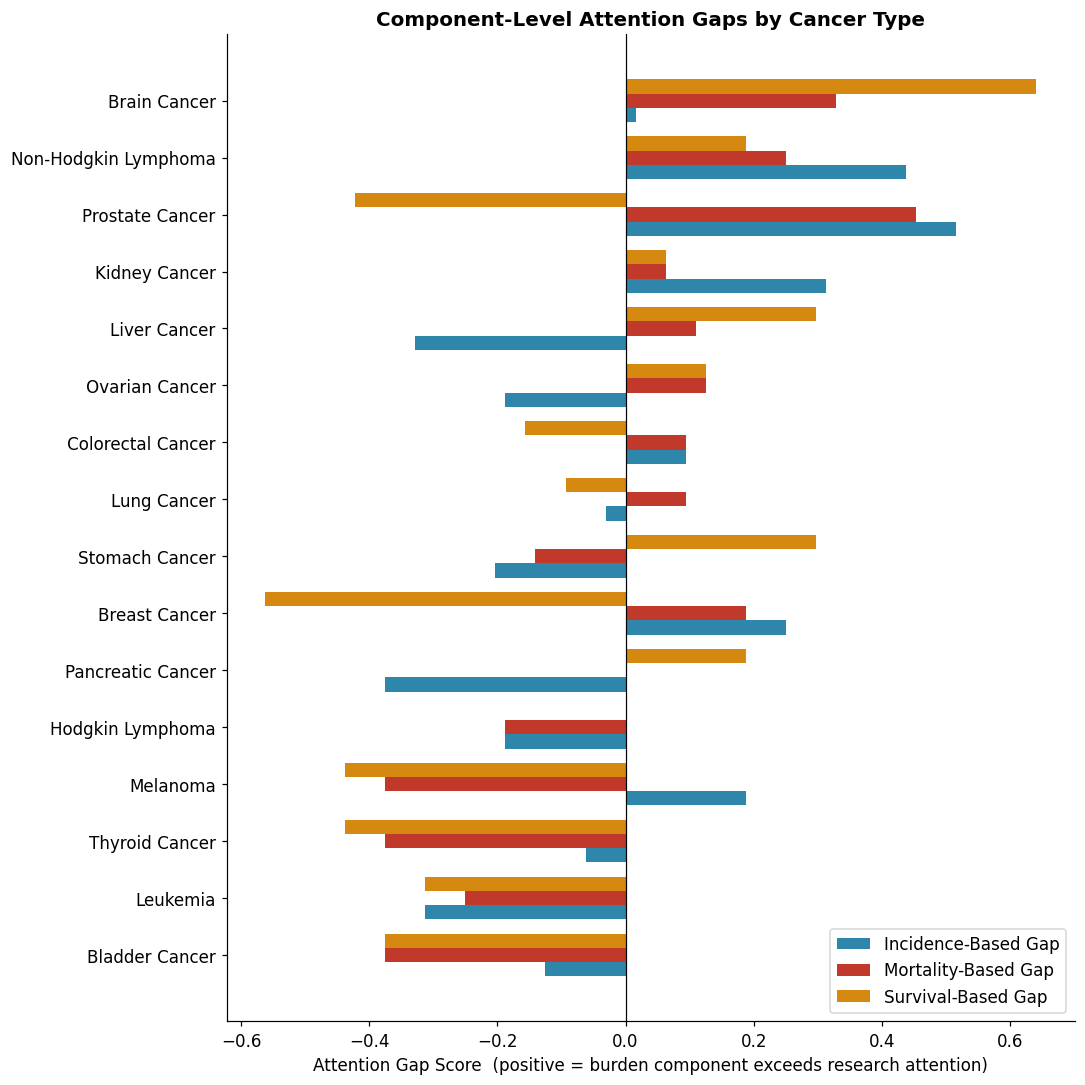

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/component_level_attention_gap_comparison.png


In [ ]:
# ============================================================
# Chart: Component-Level Attention Gaps by Cancer Type
# ============================================================

plot_df = analysis_df.sort_values("attention_gap_score", ascending=True)
y_pos = np.arange(len(plot_df))
bar_height = 0.25

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y_pos - bar_height, plot_df["incidence_attention_gap"], height=bar_height,
        color="#2E86AB", label="Incidence-Based Gap")
ax.barh(y_pos, plot_df["mortality_attention_gap"], height=bar_height,
        color="#C0392B", label="Mortality-Based Gap")
ax.barh(y_pos + bar_height, plot_df["survival_attention_gap"], height=bar_height,
        color="#D68910", label="Survival-Based Gap")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["cancer_type"])
ax.set_xlabel("Attention Gap Score  (positive = burden component exceeds research attention)")
ax.set_title("Component-Level Attention Gaps by Cancer Type")
ax.legend(loc="lower right")

fig.tight_layout()
path = CHART_DIR / "component_level_attention_gap_comparison.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
This chart checks whether the same cancer types appear under-attended across three different
definitions of disease burden — incidence, mortality, and five-year survival — rather than relying
on the composite score alone. Cancer types with consistently positive gaps across all three
components are stronger candidates for further review, since the under-attention finding does not
depend on a single burden definition. The composite Attention Gap Score (Section 5) is interpreted alongside these component-level checks, not as a replacement for them.


#### 5.7 Decision-Maker Review Table

This table consolidates the composite and component-level attention gap scores into a single,
stakeholder-ready view. It is framed for a **government research funding audience**: rather than
presenting raw scores in isolation, each cancer type is assigned a `recommended_review_priority`
based on (1) its composite attention gap category and (2) how consistently it shows a positive gap
across the three individual burden components (incidence, mortality, survival). Consistency across
components indicates the finding is not an artifact of a single burden definition, and is treated as
a stronger signal for review.


In [ ]:
# ============================================================
# Section 5.7: Decision-maker review table
# ============================================================

def recommended_review_priority(row):
    positive_components = sum([
        row["incidence_attention_gap"] > 0,
        row["mortality_attention_gap"] > 0,
        row["survival_attention_gap"] > 0,
    ])

    if row["attention_category"] == "Potentially under-attended" and positive_components >= 2:
        return "High priority for review"
    elif row["attention_category"] in ["Potentially under-attended", "Moderately under-attended"]:
        return "Medium priority for review"
    elif row["attention_category"] == "Relatively balanced":
        return "Monitor"
    else:
        return "Lower priority for review"


analysis_df["recommended_review_priority"] = analysis_df.apply(recommended_review_priority, axis=1)

review_cols = [
    "cancer_type", "attention_gap_score", "incidence_attention_gap",
    "mortality_attention_gap", "survival_attention_gap",
    "attention_category", "recommended_review_priority",
]

decision_maker_review_table = (
    analysis_df[review_cols]
    .sort_values("attention_gap_score", ascending=False)
    .reset_index(drop=True)
)

display(decision_maker_review_table)

review_table_path = TABLE_DIR / "decision_maker_review_table.csv"
decision_maker_review_table.to_csv(review_table_path, index=False)
print("Saved:", review_table_path)


,cancer_type,attention_gap_score,incidence_attention_gap,mortality_attention_gap,survival_attention_gap,attention_category,recommended_review_priority
0,Brain Cancer,0.328,0.016,0.328,0.641,Potentially under-attended,High priority for review
1,Non-Hodgkin Lymphoma,0.292,0.438,0.250,0.188,Potentially under-attended,High priority for review
2,Prostate Cancer,0.182,0.516,0.453,-0.422,Moderately under-attended,Medium priority for review
3,Kidney Cancer,0.146,0.312,0.062,0.062,Moderately under-attended,Medium priority for review
4,Liver Cancer,0.026,-0.328,0.109,0.297,Relatively balanced,Monitor
5,Ovarian Cancer,0.021,-0.188,0.125,0.125,Relatively balanced,Monitor
6,Colorectal Cancer,0.010,0.094,0.094,-0.156,Relatively balanced,Monitor
7,Lung Cancer,-0.010,-0.031,0.094,-0.094,Relatively balanced,Monitor
8,Stomach Cancer,-0.016,-0.203,-0.141,0.297,Relatively balanced,Monitor
9,Breast Cancer,-0.042,0.250,0.188,-0.562,Relatively balanced,Monitor


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/decision_maker_review_table.csv


**Interpretation:**
Cancer types marked "High priority for review" show both a positive composite attention gap and a
positive gap on at least two of the three individual burden components, indicating the finding is
robust to how burden is defined. This table supports prioritization discussions rather than a definitive funding recommendation, and is read alongside the clustering results (Section 7) and, where available, the NLP theme summary (Section 8).


<p style="font-size:15px;"><b><u>6. Exploratory Charts for Attention Gap</u></b></p>

Report-ready charts built with matplotlib only, saved as high-resolution PNGs in `CHART_DIR`.


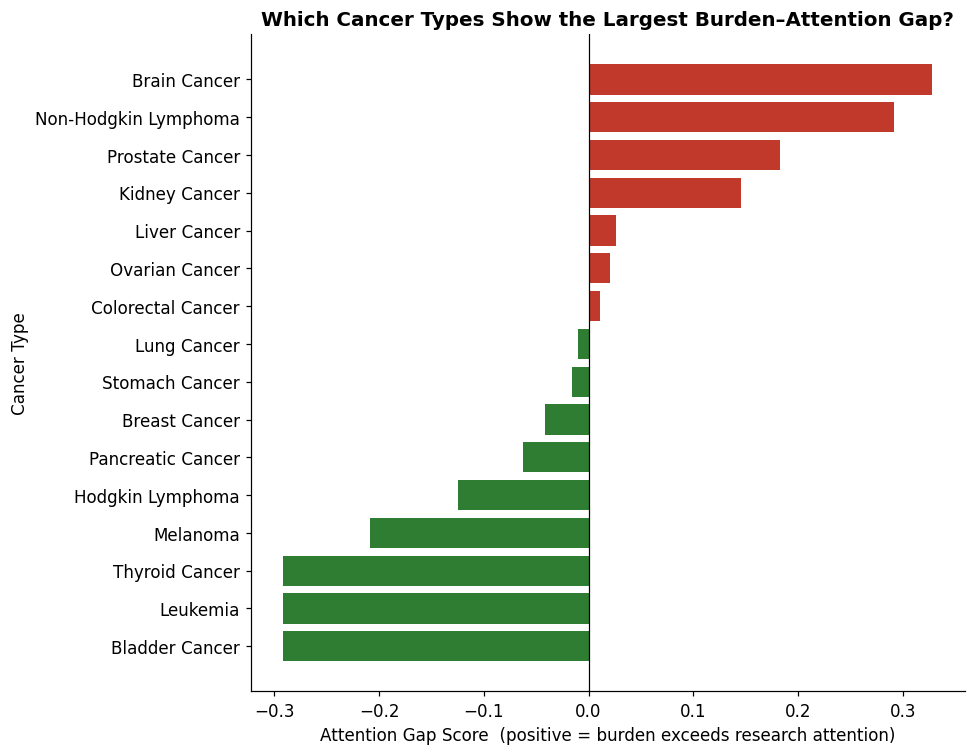

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/02_ranked_attention_gap_score.png


In [ ]:
# ============================================================
# Chart 1: Ranked Attention Gap Score (horizontal bar chart)
# ============================================================

plot_df = analysis_df.sort_values("attention_gap_score")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#C0392B" if v > 0 else "#2E7D32" for v in plot_df["attention_gap_score"]]
ax.barh(plot_df["cancer_type"], plot_df["attention_gap_score"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Which Cancer Types Show the Largest Burden–Attention Gap?")
ax.set_xlabel("Attention Gap Score  (positive = burden exceeds research attention)")
ax.set_ylabel("Cancer Type")

fig.tight_layout()
path = CHART_DIR / "02_ranked_attention_gap_score.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
Cancer types at the top of this chart have the largest positive attention gap — disease burden
that outpaces current research attention. Cancer types at the bottom have research attention that
meets or exceeds their burden. Cancers near the top may warrant closer review as potential
under-attention cases.


### Key Takeaway

The ranked attention gap chart makes it easy to identify which cancer types are most and least
aligned between burden and research attention. Cancer types with the largest positive gap are the
strongest candidates for the "potentially under-attended" findings highlighted in Section 10 (Final Analysis Direction).


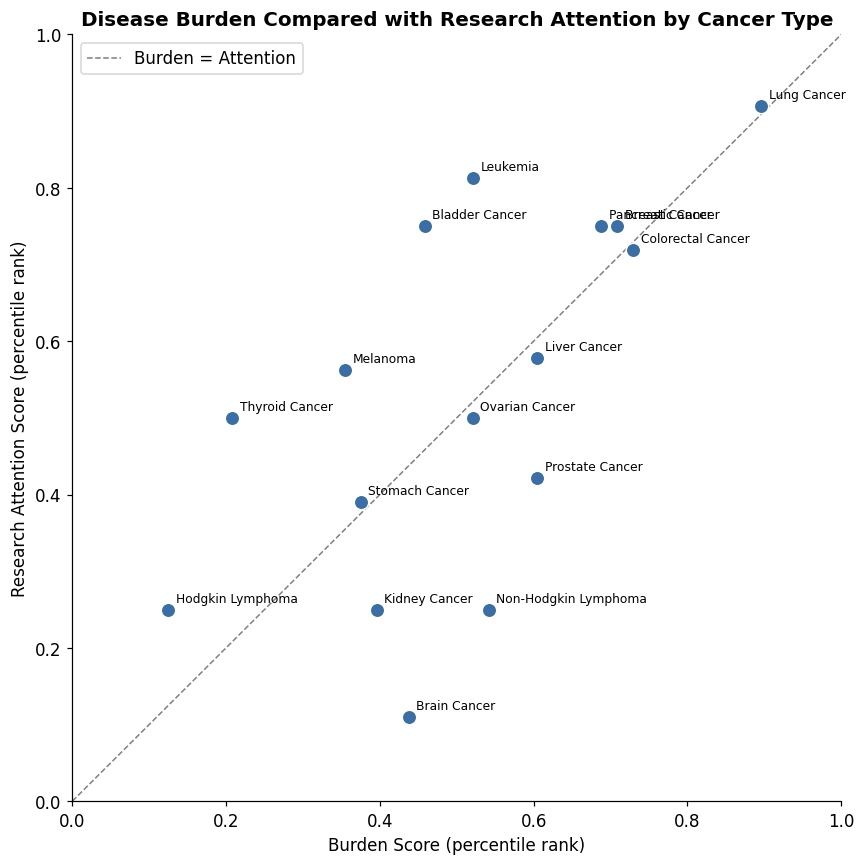

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/03_burden_vs_attention_scatter.png


In [ ]:
# ============================================================
# Chart 2: Burden Score vs Research Attention Score (scatter)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(analysis_df["burden_score"], analysis_df["research_attention_score"],
           s=90, color="#3B6EA5", edgecolor="white", zorder=3)

for _, row in analysis_df.iterrows():
    ax.annotate(row["cancer_type"], (row["burden_score"], row["research_attention_score"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

lims = [0, 1]
ax.plot(lims, lims, linestyle="--", color="gray", linewidth=1, label="Burden = Attention")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Burden Score (percentile rank)")
ax.set_ylabel("Research Attention Score (percentile rank)")
ax.set_title("Disease Burden Compared with Research Attention by Cancer Type")
ax.legend()

fig.tight_layout()
path = CHART_DIR / "03_burden_vs_attention_scatter.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
Cancer types above the diagonal have higher research attention than burden, while cancer types
below the diagonal have higher burden than research attention. Cancers below the diagonal may
warrant closer review as potential under-attention cases.


### Key Takeaway

The burden-vs-attention scatter plot visually confirms the pattern seen in the ranked bar chart:
most cancer types cluster fairly close to the diagonal, but a small number sit clearly below it.
Those cancer types are the primary candidates for the under-attention narrative in the final report.


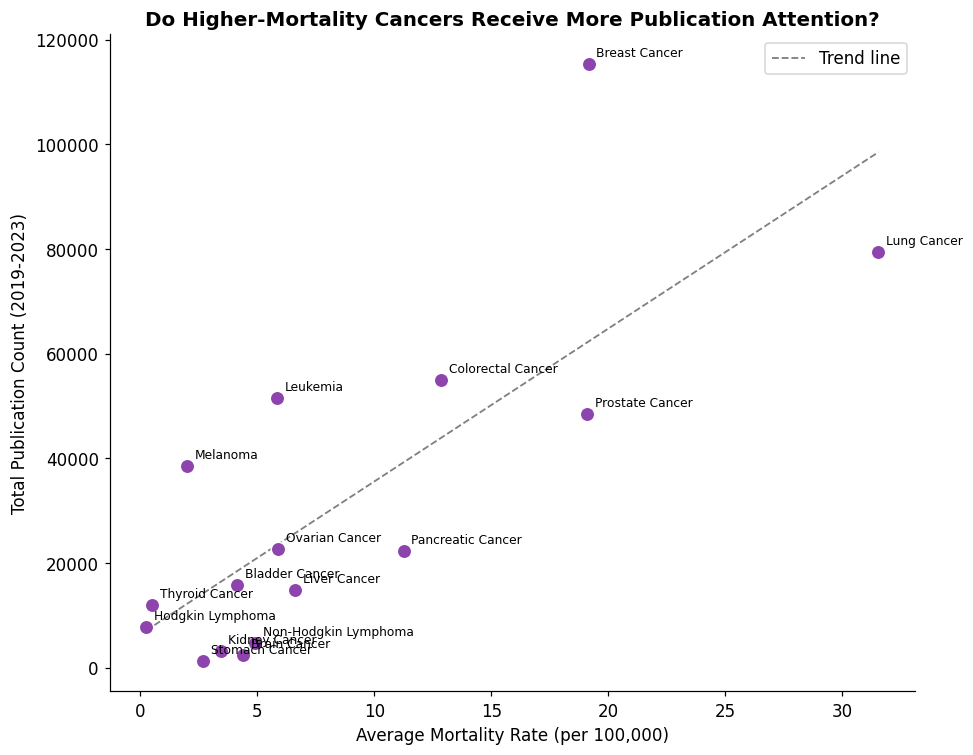

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/04_mortality_vs_publications.png


In [ ]:
# ============================================================
# Chart 3: Mortality Rate vs Total Publications (with trend line)
# ============================================================

x = analysis_df["avg_mortality_rate"].values
y = analysis_df["total_publication_count"].values

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, s=90, color="#8E44AD", edgecolor="white", zorder=3)

for _, row in analysis_df.iterrows():
    ax.annotate(row["cancer_type"], (row["avg_mortality_rate"], row["total_publication_count"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

# Simple linear trend line
z = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), linestyle="--", color="gray", linewidth=1.2, label="Trend line")

ax.set_xlabel("Average Mortality Rate (per 100,000)")
ax.set_ylabel("Total Publication Count (2019-2023)")
ax.set_title("Do Higher-Mortality Cancers Receive More Publication Attention?")
ax.legend()

fig.tight_layout()
path = CHART_DIR / "04_mortality_vs_publications.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
Each point represents a cancer type's average mortality rate against its total publication count,
with a linear trend line for reference. Points well below the trend line have fewer publications
than their mortality rate would predict.


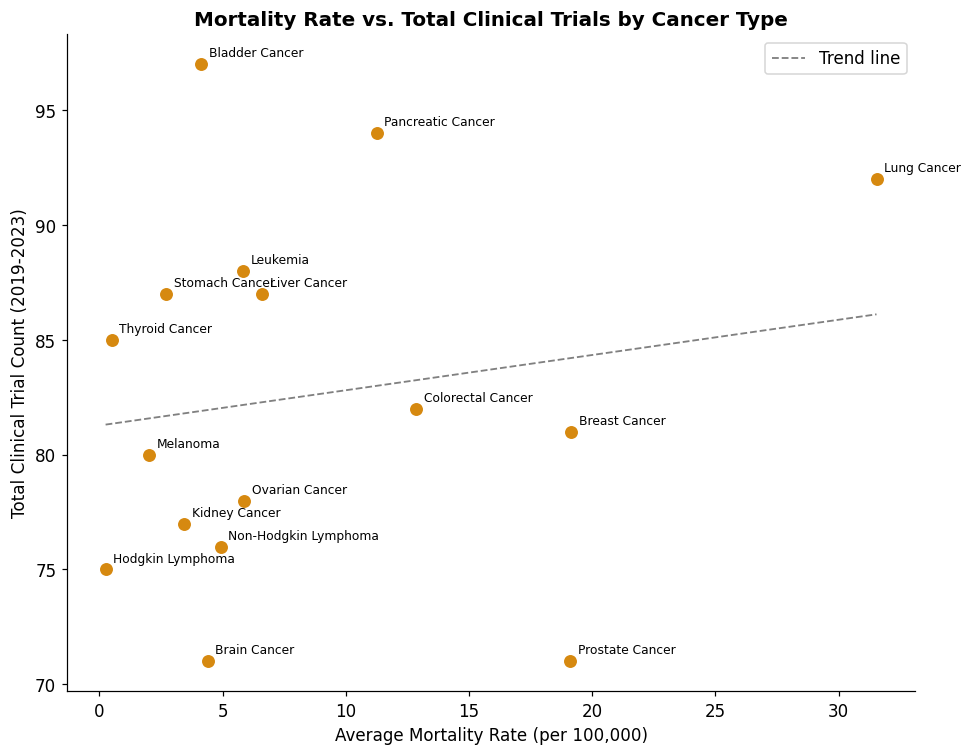

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/05_mortality_vs_trials.png


In [ ]:
# ============================================================
# Chart 4: Mortality Rate vs Total Trial Count (with trend line)
# ============================================================

x = analysis_df["avg_mortality_rate"].values
y = analysis_df["total_trial_count"].values

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, s=90, color="#D68910", edgecolor="white", zorder=3)

for _, row in analysis_df.iterrows():
    ax.annotate(row["cancer_type"], (row["avg_mortality_rate"], row["total_trial_count"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

z = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), linestyle="--", color="gray", linewidth=1.2, label="Trend line")

ax.set_xlabel("Average Mortality Rate (per 100,000)")
ax.set_ylabel("Total Clinical Trial Count (2019-2023)")
ax.set_title("Mortality Rate vs. Total Clinical Trials by Cancer Type")
ax.legend()

fig.tight_layout()
path = CHART_DIR / "05_mortality_vs_trials.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
This chart repeats the mortality comparison using clinical trial count instead of publication
count. Points below the trend line have fewer active or completed trials than their mortality rate
would predict, which is a second, independent signal of under-attention.


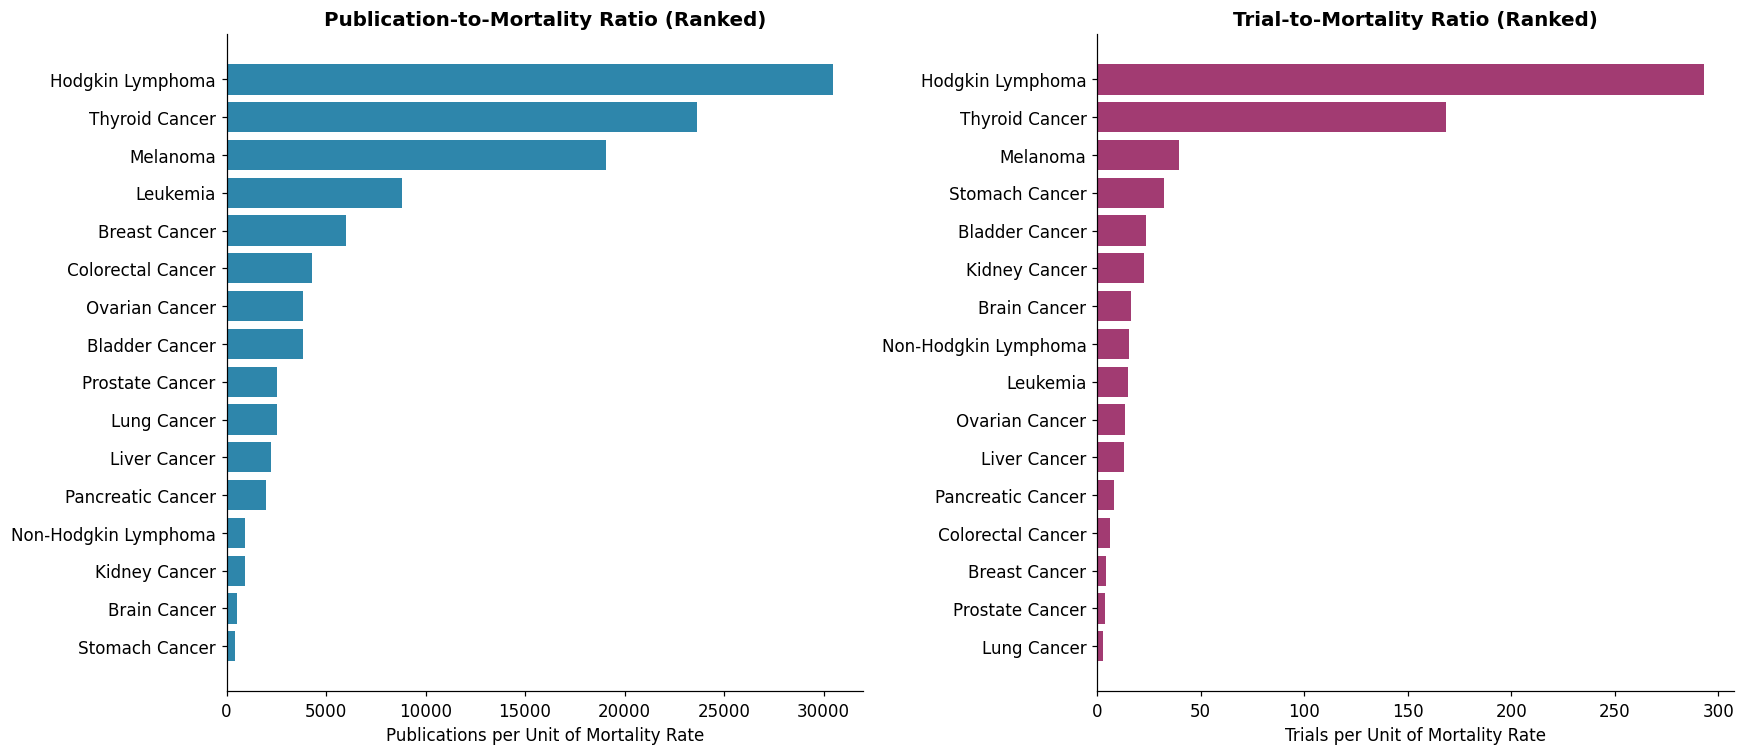

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/06_ratio_charts_publication_trial.png


In [ ]:
# ============================================================
# Chart 5 & 6: Ranked ratio charts (publication and trial, relative to mortality)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pub_ratio_sorted = analysis_df.sort_values("publication_to_mortality_ratio")
axes[0].barh(pub_ratio_sorted["cancer_type"], pub_ratio_sorted["publication_to_mortality_ratio"],
             color="#2E86AB")
axes[0].set_title("Publication-to-Mortality Ratio (Ranked)")
axes[0].set_xlabel("Publications per Unit of Mortality Rate")

trial_ratio_sorted = analysis_df.sort_values("trial_to_mortality_ratio")
axes[1].barh(trial_ratio_sorted["cancer_type"], trial_ratio_sorted["trial_to_mortality_ratio"],
             color="#A23B72")
axes[1].set_title("Trial-to-Mortality Ratio (Ranked)")
axes[1].set_xlabel("Trials per Unit of Mortality Rate")

fig.tight_layout()
path = CHART_DIR / "06_ratio_charts_publication_trial.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
These ranked ratio charts adjust publication and trial counts directly by mortality rate, so each
bar can be read as "research output per unit of disease burden." Cancer types near the bottom of
either ranking have the least research output relative to their mortality burden.


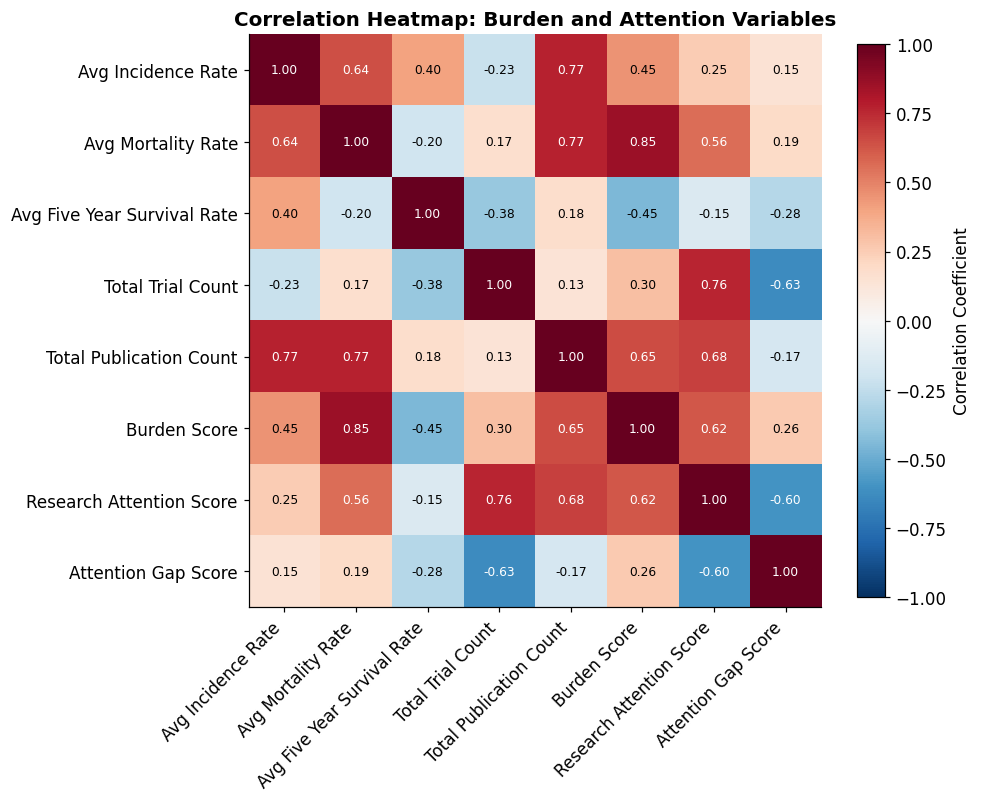

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/07_correlation_heatmap.png


In [ ]:
# ============================================================
# Chart 7: Correlation heatmap (matplotlib only)
# ============================================================

corr_vars = [
    "avg_incidence_rate", "avg_mortality_rate", "avg_five_year_survival_rate",
    "total_trial_count", "total_publication_count",
    "burden_score", "research_attention_score", "attention_gap_score",
]
corr_matrix = analysis_df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))
ax.set_xticklabels([c.replace("_", " ").title() for c in corr_vars], rotation=45, ha="right")
ax.set_yticklabels([c.replace("_", " ").title() for c in corr_vars])

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation Coefficient")
ax.set_title("Correlation Heatmap: Burden and Attention Variables")

fig.tight_layout()
path = CHART_DIR / "07_correlation_heatmap.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Chart interpretation:**
The correlation heatmap summarizes how strongly the burden and attention variables move together.
Weak correlations between mortality/incidence and publication/trial counts are consistent with the
attention gap the other charts in this section point to.


**Sensitivity Note:**
Because mortality and five-year survival are conceptually related, the correlation heatmap above is
used as a sensitivity check on the composite Attention Gap Score. In this dataset, the correlation
between average mortality rate and average five-year survival rate at the cancer-type level is
approximately **-0.20** — a weak-to-moderate negative relationship, not a strong collinearity. This
indicates the two components carry meaningfully different information rather than duplicating one
another, which supports examining them separately in the Section 5.6 component-level checks. Even
so, because the two measures are conceptually linked, the composite Attention Gap Score is interpreted as a broad prioritization index rather than as three fully independent burden measures.


<p style="font-size:15px;"><b><u>7. Clustering Model Comparison</u></b></p>

Clustering is used only as a supporting method: to group the 16 cancer types into interpretable
burden-attention profiles. Features are standardized, K-means is tested for k = 2 to 5 using the
silhouette score, and a final k is selected based on interpretability.


In [ ]:
# ============================================================
# Standardize features and run K-means for k = 2, 3, 4, 5
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = [
    "avg_incidence_rate", "avg_mortality_rate", "avg_five_year_survival_rate",
    "total_trial_count", "total_publication_count",
    "burden_score", "research_attention_score", "attention_gap_score",
]

X = analysis_df[cluster_features].values
X_scaled = StandardScaler().fit_transform(X)

silhouette_results = []
kmeans_models = {}

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append({"k": k, "silhouette_score": score})
    kmeans_models[k] = (km, labels)

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

silhouette_path = TABLE_DIR / "cluster_attempts_silhouette_scores.csv"
silhouette_df.to_csv(silhouette_path, index=False)
print("Saved:", silhouette_path)


,k,silhouette_score
0,2,0.304
1,3,0.268
2,4,0.273
3,5,0.242


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/cluster_attempts_silhouette_scores.csv


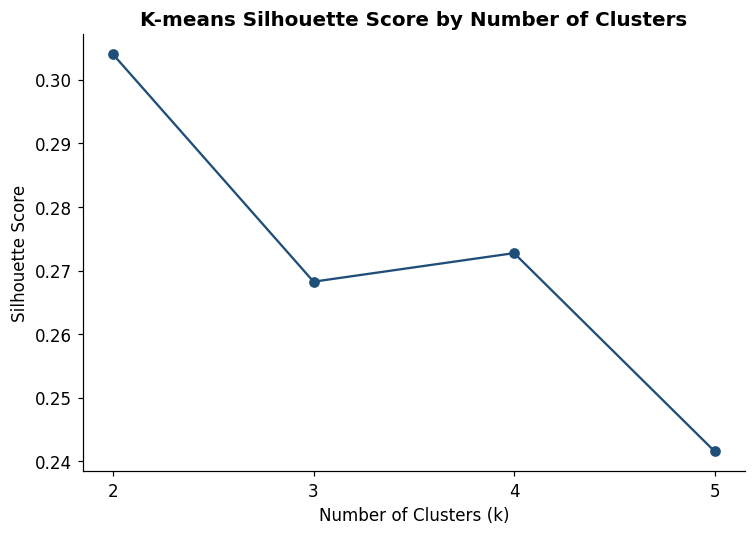

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/08_silhouette_scores_by_k.png


In [ ]:
# ============================================================
# Plot silhouette score by k
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o", color="#1F4E79")
ax.set_xticks(silhouette_df["k"])
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("K-means Silhouette Score by Number of Clusters")

fig.tight_layout()
path = CHART_DIR / "08_silhouette_scores_by_k.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


**Note on Cluster Selection:**
The silhouette score in the table and chart above may favor k = 2, which typically produces the
most mathematically separable clusters for a small dataset such as this one (16 cancer types).
However, k = 2 collapses the data into a single "high" and "low" group, which is too coarse to
support a decision-maker looking for differentiated review priorities. **k = 3 is selected** because
it provides an additional, decision-relevant distinction — separating cancer types with high burden
and low attention from those with high burden and high attention — while remaining small enough to
stay interpretable. This is consistent with treating clustering as a **supporting method**: cluster
results are used only to the extent that they add interpretable value alongside the composite
Attention Gap Score, not as a standalone conclusion.


In [ ]:
# ============================================================
# Select preferred solution (k = 3) and profile the clusters
# ============================================================

SELECTED_K = 3
km_selected, cluster_labels = kmeans_models[SELECTED_K]
analysis_df["cluster"] = cluster_labels

cluster_profile = (
    analysis_df.groupby("cluster")[cluster_features + ["cancer_type"]]
    .agg({**{c: "mean" for c in cluster_features}, "cancer_type": lambda s: ", ".join(s)})
    .rename(columns={"cancer_type": "cancer_types_in_cluster"})
    .reset_index()
)

display(cluster_profile)

cluster_profile_path = TABLE_DIR / "cluster_profile_summary.csv"
cluster_profile.to_csv(cluster_profile_path, index=False)
print("Saved:", cluster_profile_path)

# NOTE: cluster numbers are arbitrary; the interpretation below should be checked
# against the actual profile table above and relabeled if needed.
print("\nReference interpretation (verify against the table above):")
print("Cluster with highest burden_score AND highest research_attention_score  -> High burden / high attention")
print("Cluster with high burden_score but lower research_attention_score      -> Higher burden / lower attention")
print("Cluster with lower burden_score and comparatively higher attention     -> Lower burden / relatively higher attention")


,cluster,avg_incidence_rate,avg_mortality_rate,avg_five_year_survival_rate,total_trial_count,total_publication_count,burden_score,research_attention_score,attention_gap_score,cancer_types_in_cluster
0,0,125.914,19.132,96.290,76.000,"81,850.500",0.656,0.586,0.070,"Breast Cancer, Prostate Cancer"
1,1,12.249,3.016,72.280,78.625,"11,551.500",0.370,0.352,0.018,"Brain Cancer, Hodgkin Lymphoma, Kidney Cancer,..."
2,2,21.422,12.043,49.300,90.000,"39,845.667",0.649,0.753,-0.103,"Bladder Cancer, Colorectal Cancer, Leukemia, L..."


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/cluster_profile_summary.csv

Reference interpretation (verify against the table above):
Cluster with highest burden_score AND highest research_attention_score  -> High burden / high attention
Cluster with high burden_score but lower research_attention_score      -> Higher burden / lower attention
Cluster with lower burden_score and comparatively higher attention     -> Lower burden / relatively higher attention


In [ ]:
# ============================================================
# Automatically label clusters based on average burden and attention scores
# ============================================================

# A cluster is labeled by comparing its mean burden_score and mean research_attention_score
# to the overall (all-cancer) median, rather than relying on arbitrary cluster numbers.
overall_burden_median = analysis_df["burden_score"].median()
overall_attention_median = analysis_df["research_attention_score"].median()


def label_cluster(row):
    high_burden = row["burden_score"] >= overall_burden_median
    high_attention = row["research_attention_score"] >= overall_attention_median
    if high_burden and high_attention:
        return "High burden / high attention"
    elif high_burden and not high_attention:
        return "High burden / low attention"
    elif not high_burden and high_attention:
        return "Low burden / high attention"
    else:
        return "Low burden / low attention"


cluster_profile["cluster_label"] = cluster_profile.apply(label_cluster, axis=1)

label_map = dict(zip(cluster_profile["cluster"], cluster_profile["cluster_label"]))
analysis_df["cluster_label"] = analysis_df["cluster"].map(label_map)

display(cluster_profile[["cluster", "burden_score", "research_attention_score", "cluster_label"]])
print("\nCluster labels assigned automatically based on burden/attention medians:")
for c, label in label_map.items():
    print(f" - Cluster {c}: {label}")


,cluster,burden_score,research_attention_score,cluster_label
0,0,0.656,0.586,High burden / high attention
1,1,0.370,0.352,Low burden / low attention
2,2,0.649,0.753,High burden / high attention



Cluster labels assigned automatically based on burden/attention medians:
 - Cluster 0: High burden / high attention
 - Cluster 1: Low burden / low attention
 - Cluster 2: High burden / high attention


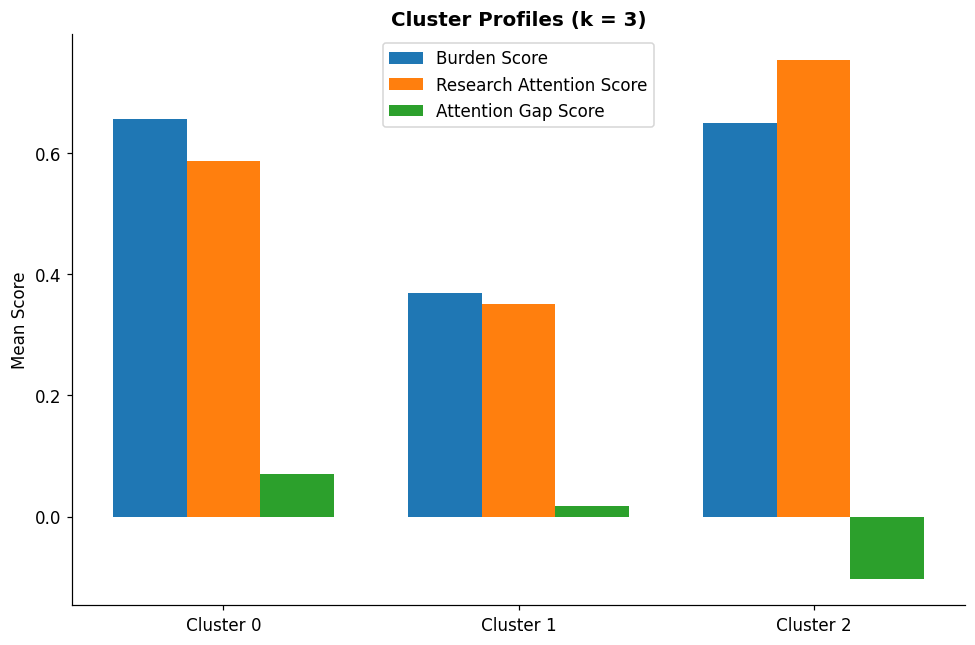

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/09_cluster_profile_bars.png


In [ ]:
# ============================================================
# Cluster profile chart (mean feature values by cluster)
# ============================================================

profile_plot_vars = ["burden_score", "research_attention_score", "attention_gap_score"]

fig, ax = plt.subplots(figsize=(9, 6))
width = 0.25
x_pos = np.arange(len(cluster_profile))

for i, var in enumerate(profile_plot_vars):
    ax.bar(x_pos + i * width, cluster_profile[var], width=width, label=var.replace("_", " ").title())

ax.set_xticks(x_pos + width)
ax.set_xticklabels([f"Cluster {c}" for c in cluster_profile["cluster"]])
ax.set_ylabel("Mean Score")
ax.set_title(f"Cluster Profiles (k = {SELECTED_K})")
ax.legend()

fig.tight_layout()
path = CHART_DIR / "09_cluster_profile_bars.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


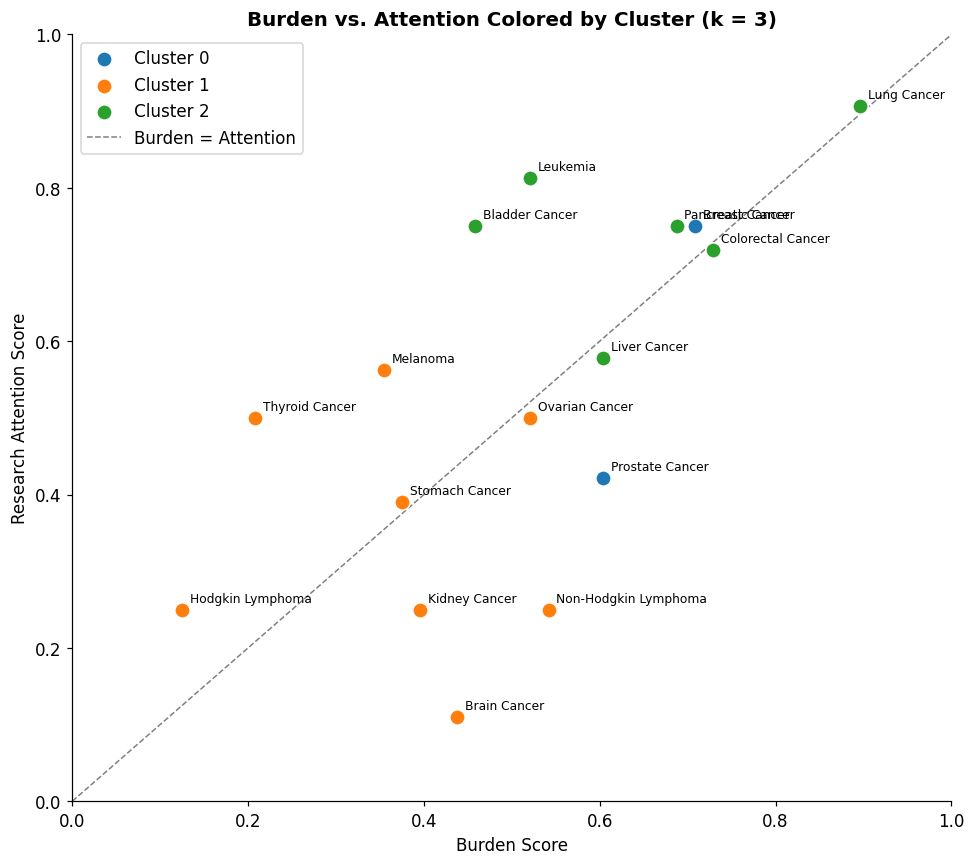

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/10_cluster_scatter_burden_vs_attention.png


In [ ]:
# ============================================================
# Scatter plot: burden vs attention, colored by cluster
# ============================================================

fig, ax = plt.subplots(figsize=(9, 8))
cmap = plt.get_cmap("tab10")

for c in sorted(analysis_df["cluster"].unique()):
    subset = analysis_df[analysis_df["cluster"] == c]
    ax.scatter(subset["burden_score"], subset["research_attention_score"],
               s=100, color=cmap(c), label=f"Cluster {c}", edgecolor="white", zorder=3)
    for _, row in subset.iterrows():
        ax.annotate(row["cancer_type"], (row["burden_score"], row["research_attention_score"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Burden = Attention")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Burden Score")
ax.set_ylabel("Research Attention Score")
ax.set_title(f"Burden vs. Attention Colored by Cluster (k = {SELECTED_K})")
ax.legend()

fig.tight_layout()
path = CHART_DIR / "10_cluster_scatter_burden_vs_attention.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


### Key Takeaway

The clustering results group the 16 cancer types into a small number of interpretable
burden-attention profiles (now automatically labeled above, rather than left as arbitrary cluster
numbers). Cancer types in a "high burden / low attention" cluster are the strongest candidates for
the under-attention findings highlighted in Section 10 (Final Analysis Direction), while clusters
with balanced or high-attention profiles provide useful contrast.


In [ ]:
# ============================================================
# Save the analysis-ready dataset with cluster labels
# ============================================================

clustered_output_path = PROCESSED_DIR / "analysis_ready_with_clusters.csv"
analysis_df.to_csv(clustered_output_path, index=False)
print("Saved:", clustered_output_path)


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data/analysis_ready_with_clusters.csv


<p style="font-size:15px;"><b><u>8. Optional NLP / Topic Modeling Exploration</u></b></p>

NLP/topic modeling is treated as an exploratory supplement and is included only if the results provide
interpretable research-theme evidence. This section is intentionally lightweight: it only runs if a
text column is available, and it stops at simple, interpretable outputs (TF-IDF top terms, and NMF
topics only if there is enough text).


In [ ]:
# ============================================================
# Check for available text and run TF-IDF if present
# ============================================================

import re
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Custom stopword list: sklearn's built-in English stopwords, extended with generic
# oncology terms that appear across nearly all cancer types and add no discriminating value
CUSTOM_ONCOLOGY_STOPWORDS = {
    "cancer", "cancers", "patient", "patients", "treatment", "treatments",
    "trial", "trials", "study", "studies", "clinical", "therapy", "therapies",
    "disease", "diseases", "tumor", "tumors", "tumour", "tumours", "cell", "cells",
}
COMBINED_STOPWORDS = list(ENGLISH_STOP_WORDS.union(CUSTOM_ONCOLOGY_STOPWORDS))

text_col_priority = ["combined_text_sample", "publication_text_sample", "trial_text_sample"]
text_col = next((c for c in text_col_priority if c in analysis_df.columns), None)

MIN_WORDS_FOR_NLP = 20  # minimum average words per cancer type to attempt NLP

nlp_ran = False

if text_col is None:
    print("No text columns are available in analysis_df. Skipping NLP section.")
else:
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    analysis_df["clean_text"] = analysis_df[text_col].fillna("").apply(clean_text)
    avg_words = analysis_df["clean_text"].str.split().apply(len).mean()
    print(f"Using text column: {text_col}")
    print(f"Average word count per cancer type: {avg_words:.1f}")

    if avg_words < MIN_WORDS_FOR_NLP or analysis_df["clean_text"].str.strip().eq("").all():
        print("\nText volume is too sparse for reliable topic modeling. "
              "NLP was considered but not carried forward due to limited available text.")
    else:
        nlp_ran = True
        vectorizer = TfidfVectorizer(stop_words=COMBINED_STOPWORDS, max_features=500, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(analysis_df["clean_text"])
        terms = np.array(vectorizer.get_feature_names_out())

        top_terms_records = []
        for i, cancer in enumerate(analysis_df["cancer_type"]):
            row = tfidf_matrix[i].toarray().flatten()
            top_idx = row.argsort()[::-1][:10]
            top_terms_records.append({
                "cancer_type": cancer,
                "top_terms": ", ".join(terms[top_idx]),
            })

        top_terms_df = pd.DataFrame(top_terms_records)
        display(top_terms_df)

        top_terms_path = TABLE_DIR / "tfidf_top_terms_by_cancer.csv"
        top_terms_df.to_csv(top_terms_path, index=False)
        print("Saved:", top_terms_path)


Using text column: combined_text_sample
Average word count per cancer type: 701.9


,cancer_type,top_terms
0,Bladder Cancer,"bladder, organoids, renal, common, mouse, urot..."
1,Brain Cancer,"brain, opn, bbb, metastasis, glioma, macrophag..."
2,Breast Cancer,"breast, ibr, based, day, group, quality, targe..."
3,Colorectal Cancer,"crc, colorectal, colon, young, incidence, here..."
4,Hodgkin Lymphoma,"hodgkin, lymphoma, aspen, neoplastic, radiatio..."
5,Kidney Cancer,"rcc, kidney, renal, factors, risk, carcinoma, ..."
6,Leukemia,"leukemia, myeloid, mll, acute, marrow, arm, vt..."
7,Liver Cancer,"liver, limore, transcriptomic, landscape, hepa..."
8,Lung Cancer,"lung, vo, staging, respiratory, kinetic, exerc..."
9,Melanoma,"melanoma, cutaneous, skin, recommendations, di..."


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/tfidf_top_terms_by_cancer.csv


In [ ]:
# ============================================================
# Optional NMF topic modeling (only runs if TF-IDF succeeded above)
# ============================================================

if nlp_ran:
    from sklearn.decomposition import NMF

    N_TOPICS = 5
    nmf_model = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=500)
    nmf_model.fit(tfidf_matrix)

    topic_records = []
    for topic_idx, topic in enumerate(nmf_model.components_):
        top_idx = topic.argsort()[::-1][:8]
        topic_records.append({
            "topic": f"Topic {topic_idx}",
            "top_keywords": ", ".join(terms[top_idx]),
        })

    topic_df = pd.DataFrame(topic_records)
    display(topic_df)

    topic_path = TABLE_DIR / "topic_modeling_attempts.csv"
    topic_df.to_csv(topic_path, index=False)
    print("Saved:", topic_path)
else:
    print("Skipped: NMF topic modeling requires the TF-IDF step above to have run.")


,topic,top_keywords
0,Topic 0,"bladder, rcc, renal, kidney, organoids, factor..."
1,Topic 1,"lymphoma, hodgkin, aspen, breast, radiation, c..."
2,Topic 2,"prostate, lung, vo, thyroid, intervention, reh..."
3,Topic 3,"melanoma, pancreatic, ovarian, gemcitabine, wo..."
4,Topic 4,"liver, crc, gastric, colorectal, million, brai..."


Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Tables/topic_modeling_attempts.csv


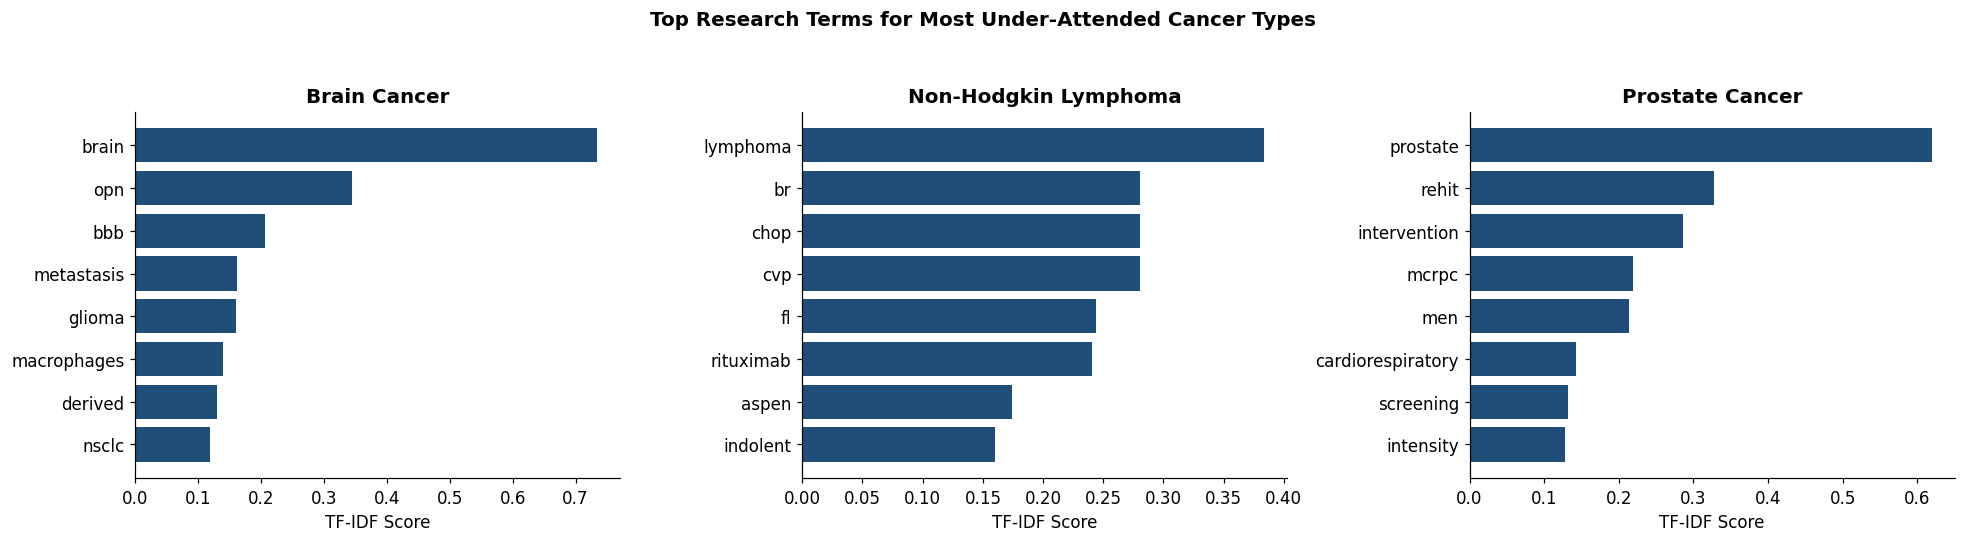

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/11_top_terms_under_attended_cancers.png


In [ ]:
# ============================================================
# Simple chart: top terms for the most under-attended cancers
# ============================================================

if nlp_ran:
    under_attended = analysis_df.sort_values("attention_gap_score", ascending=False).head(3)

    fig, axes = plt.subplots(1, len(under_attended), figsize=(6 * len(under_attended), 5))
    if len(under_attended) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, under_attended.iterrows()):
        idx = analysis_df.index[analysis_df["cancer_type"] == row["cancer_type"]][0]
        tfidf_row = tfidf_matrix[idx].toarray().flatten()
        top_idx = tfidf_row.argsort()[::-1][:8]
        top_words = terms[top_idx]
        top_scores = tfidf_row[top_idx]

        ax.barh(top_words[::-1], top_scores[::-1], color="#1F4E79")
        ax.set_title(row["cancer_type"])
        ax.set_xlabel("TF-IDF Score")

    fig.suptitle("Top Research Terms for Most Under-Attended Cancer Types", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    path = CHART_DIR / "11_top_terms_under_attended_cancers.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
else:
    print("Skipped: no NLP results available to chart.")


### Key Takeaway

Where sufficient text was available, the TF-IDF and NMF results surface the research sub-themes
associated with the most under-attended cancer types, which can add narrative color to the
quantitative attention gap findings.

Where text volume was too sparse, this section is documented as considered-but-limited, consistent
with treating NLP as an exploratory supplement rather than a required component of the analysis.


<p style="font-size:15px;"><b><u>9. Analyses Considered but Not Used</u></b></p>

A few additional methods were discussed while scoping this project, but are **not** carried into the
final report:

- **Time-series analysis** — Not used. The dataset only covers 2019-2023, a short window that is also
  affected by COVID-era disruptions to clinical trial activity and publication rates. Any trend
  detected over five years would be unreliable and difficult to separate from pandemic effects.
- **Anomaly detection** — Not used. The core research question ("are resources aligned with burden?")
  is answered more directly and more transparently through the explicit attention gap metrics in
  Section 5 than through outlier-detection methods.
- **Dimension reduction / PCA** — Considered, but not selected. While PCA could compress the feature
  set, the resulting components are harder for a non-technical audience (e.g., decision-makers) to
  interpret than the burden score / research attention score already used here.
- **Overall approach** — The final report focuses on: (1) the composite attention gap score,
  (2) the incidence-, mortality-, and survival-based component checks, (3) selected
  burden-attention visualizations, (4) clustering into interpretable burden-attention profiles,
  if interpretable, and (5) the NLP/topic summary, if the text results provide meaningful insight.


## Method Selection Summary

| Method | Tested in Working Notebook? | Selected for Final Report? | Final Report Placement | Reason |
|---|---|---|---|---|
| Composite Attention Gap Score | Yes | Yes, primary metric | Main results | Combines incidence, mortality, survival, and research-attention indicators into one comparable score |
| Incidence-based component check | Yes | Yes, supporting check | Supporting results | Captures patient volume, treatment demand, and health-system burden; relevant even for cancers with favorable outcomes |
| Mortality-based component check | Yes | Yes, supporting check | Supporting results | Captures disease severity and fatality burden |
| Survival-based component check | Yes | Yes, supporting check | Supporting results | Captures poor-prognosis burden; interpreted alongside mortality due to conceptual overlap |
| Publication-to-mortality ratio | Yes | Yes, supporting validation metric | Supporting results | Easy to interpret and directly adjusts publications by mortality burden |
| Trial-to-mortality ratio | Yes | Yes, supporting validation metric | Supporting results | Shows clinical trial attention relative to disease burden |
| Publication-to-incidence ratio | Yes | Working notebook only, supporting sensitivity check | Working notebook only | Retained for robustness testing; not part of the main report narrative |
| Trial-to-incidence ratio | Yes | Working notebook only, supporting sensitivity check | Working notebook only | Retained for robustness testing; not part of the main report narrative |
| Correlation / sensitivity check (mortality vs. survival) | Yes | Yes, sensitivity check | Appendix | Confirms whether the composite score's burden components are collinear before it is interpreted |
| K-means clustering | Yes | Conditional, supporting method | Conditional | Included if cluster profiles are interpretable and add decision-making value |
| TF-IDF / topic modeling | Yes | Conditional, supporting method | Conditional | Included only if it adds meaningful context beyond the quantitative metrics |
| Time-series analysis | Considered | No | Working notebook only | Five-year window is short and may be affected by COVID-era disruption |
| Anomaly detection | Considered | No | Working notebook only | Research question is better answered through direct attention gap metrics |
| PCA / dimension reduction | Considered | No | Working notebook only | Less directly interpretable for decision-makers |


<p style="font-size:15px;"><b><u>10. Final Analysis Direction</u></b></p>

Based on the working analysis, the final report focuses on a smaller set of analyses that
directly answer the research question and support decision-making.

The final analysis includes:

1. Composite Attention Gap Score as the primary prioritization metric.
2. Component-level checks for incidence, mortality, and five-year survival.
3. Selected burden-attention visualizations, including the ranked gap chart, component-level gap
   chart, and burden-versus-attention scatter plot.
4. K-means clustering only if the final cluster profiles are interpretable.
5. NLP/TF-IDF only if the text results provide meaningful research-theme insight.

Exploratory analyses, additional charts, and methods not selected for the final report remain
documented in this working notebook.

Supporting references and data sources are documented in Section 11, and a full listing of saved output files appears in Section 13 (Output Verification).


<p style="font-size:15px;"><b><u>11. References and Data Sources</u></b></p>

This working notebook uses publicly available data sources and supporting literature relevant to
cancer burden, clinical trial activity, publication attention, and research prioritization.

#### Data Sources

- National Cancer Institute. SEER Cancer Stat Facts.
- ClinicalTrials.gov. U.S. National Library of Medicine.
- National Center for Biotechnology Information. PubMed / NCBI E-utilities.

#### Supporting Literature

- Gross, C. P., Anderson, G. F., & Powe, N. R. (1999). The relation between funding by the National
  Institutes of Health and the burden of disease. *New England Journal of Medicine*.
- Carter, A. J. R., & Nguyen, C. N. (2012). A comparison of cancer burden and research spending
  reveals discrepancies in the distribution of research funding. *BMC Public Health*.
- Unger, J. M., Vaidya, R., Hershman, D. L., Minasian, L. M., & Fleury, M. E. (2019). Systematic
  review and meta-analysis of the magnitude of structural, clinical, physician, and patient barriers
  to cancer clinical trial participation. *Journal of the National Cancer Institute*.
- Yegros-Yegros, A., Rafols, I., & D'Este, P. (2015). Does interdisciplinary research lead to higher
  citation impact?


<p style="font-size:15px;"><b><u>12. Supplemental Visualization Options Considered</u></b></p>

Beyond the required chart set, three additional matplotlib-only visuals are included here as
**exploratory options**. These charts are exploratory in nature and may not be used in the
final report; they are kept here for reference and to document the full range of visuals
considered while developing the reporting charts in Section 6:

- **Bubble chart** — adds a third dimension (publication volume) on top of the mortality-vs-trials
  scatter, so burden, trial activity, and publication volume are visible in a single chart.
- **Dumbbell / slope chart** — directly compares each cancer type's burden rank against its
  research-attention rank, making rank *reversals* (the clearest sign of a gap) easy to spot.
- **Small-multiples panel** — one mini bar per cancer type showing burden vs. attention side by
  side, useful as a presentation appendix slide.


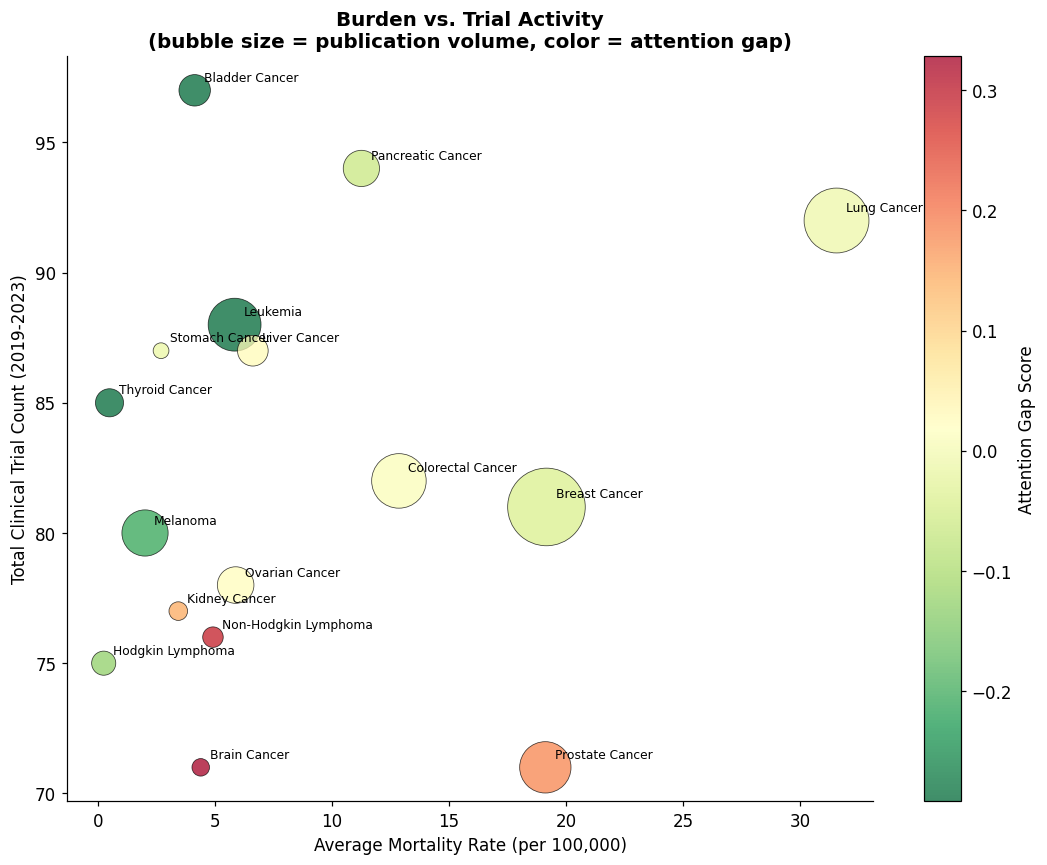

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/12_advanced_bubble_chart.png


In [ ]:
# ============================================================
# Advanced Chart 1: Bubble chart
# mortality (x) vs trials (y), bubble size = publication count
# ============================================================

x = analysis_df["avg_mortality_rate"]
y = analysis_df["total_trial_count"]
size = (analysis_df["total_publication_count"] / analysis_df["total_publication_count"].max()) * 2500 + 80

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(x, y, s=size, c=analysis_df["attention_gap_score"],
                      cmap="RdYlGn_r", alpha=0.75, edgecolor="black", linewidth=0.5)

for _, row in analysis_df.iterrows():
    ax.annotate(row["cancer_type"], (row["avg_mortality_rate"], row["total_trial_count"]),
                fontsize=8, xytext=(6, 6), textcoords="offset points")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Attention Gap Score")

ax.set_xlabel("Average Mortality Rate (per 100,000)")
ax.set_ylabel("Total Clinical Trial Count (2019-2023)")
ax.set_title("Burden vs. Trial Activity\n(bubble size = publication volume, color = attention gap)")

fig.tight_layout()
path = CHART_DIR / "12_advanced_bubble_chart.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


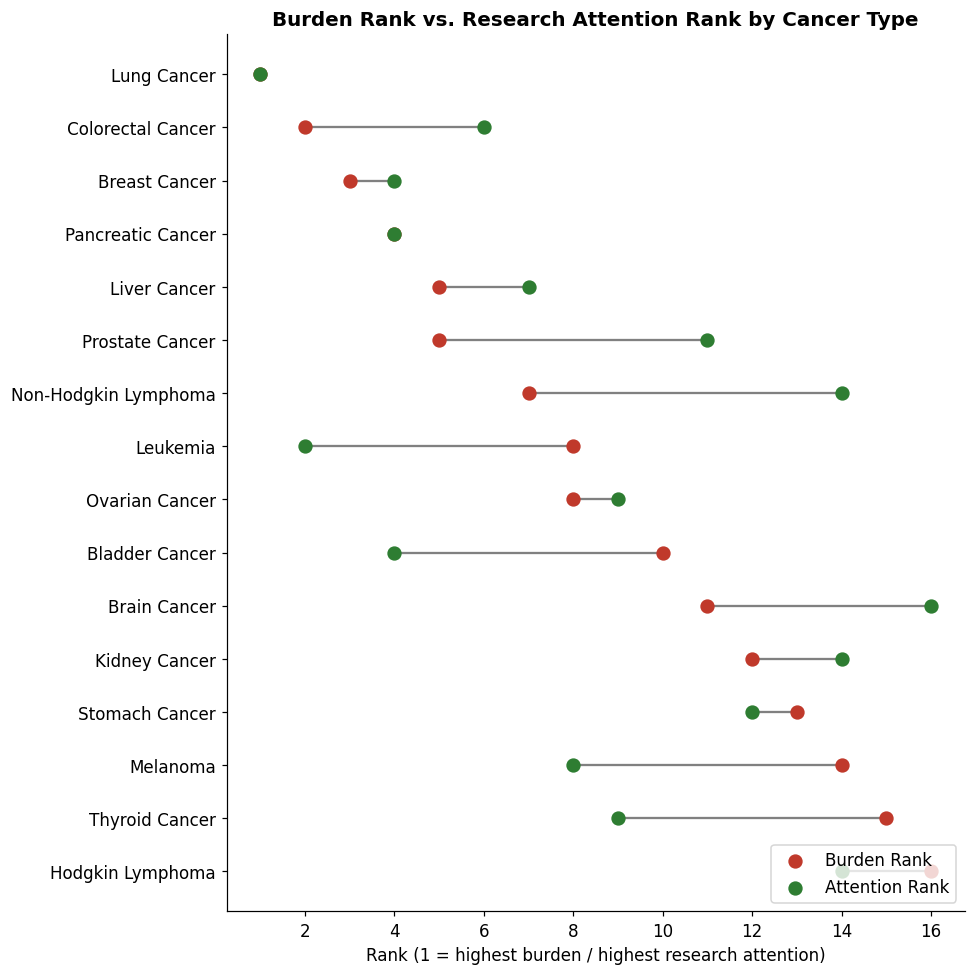

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/13_advanced_dumbbell_rank_chart.png


In [ ]:
# ============================================================
# Advanced Chart 2: Dumbbell / slope chart of burden rank vs attention rank
# ============================================================

rank_df = analysis_df.copy()
rank_df["burden_rank"] = rank_df["burden_score"].rank(ascending=False).astype(int)
rank_df["attention_rank"] = rank_df["research_attention_score"].rank(ascending=False).astype(int)
rank_df = rank_df.sort_values("burden_rank")

fig, ax = plt.subplots(figsize=(9, 9))

for i, row in enumerate(rank_df.itertuples()):
    ax.plot([row.burden_rank, row.attention_rank], [i, i],
            color="gray", linewidth=1.5, zorder=1)
    ax.scatter(row.burden_rank, i, color="#C0392B", s=70, zorder=2, label="Burden Rank" if i == 0 else "")
    ax.scatter(row.attention_rank, i, color="#2E7D32", s=70, zorder=2, label="Attention Rank" if i == 0 else "")

ax.set_yticks(range(len(rank_df)))
ax.set_yticklabels(rank_df["cancer_type"])
ax.set_xlabel("Rank (1 = highest burden / highest research attention)")
ax.set_title("Burden Rank vs. Research Attention Rank by Cancer Type")
ax.invert_yaxis()
ax.legend(loc="lower right")

fig.tight_layout()
path = CHART_DIR / "13_advanced_dumbbell_rank_chart.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


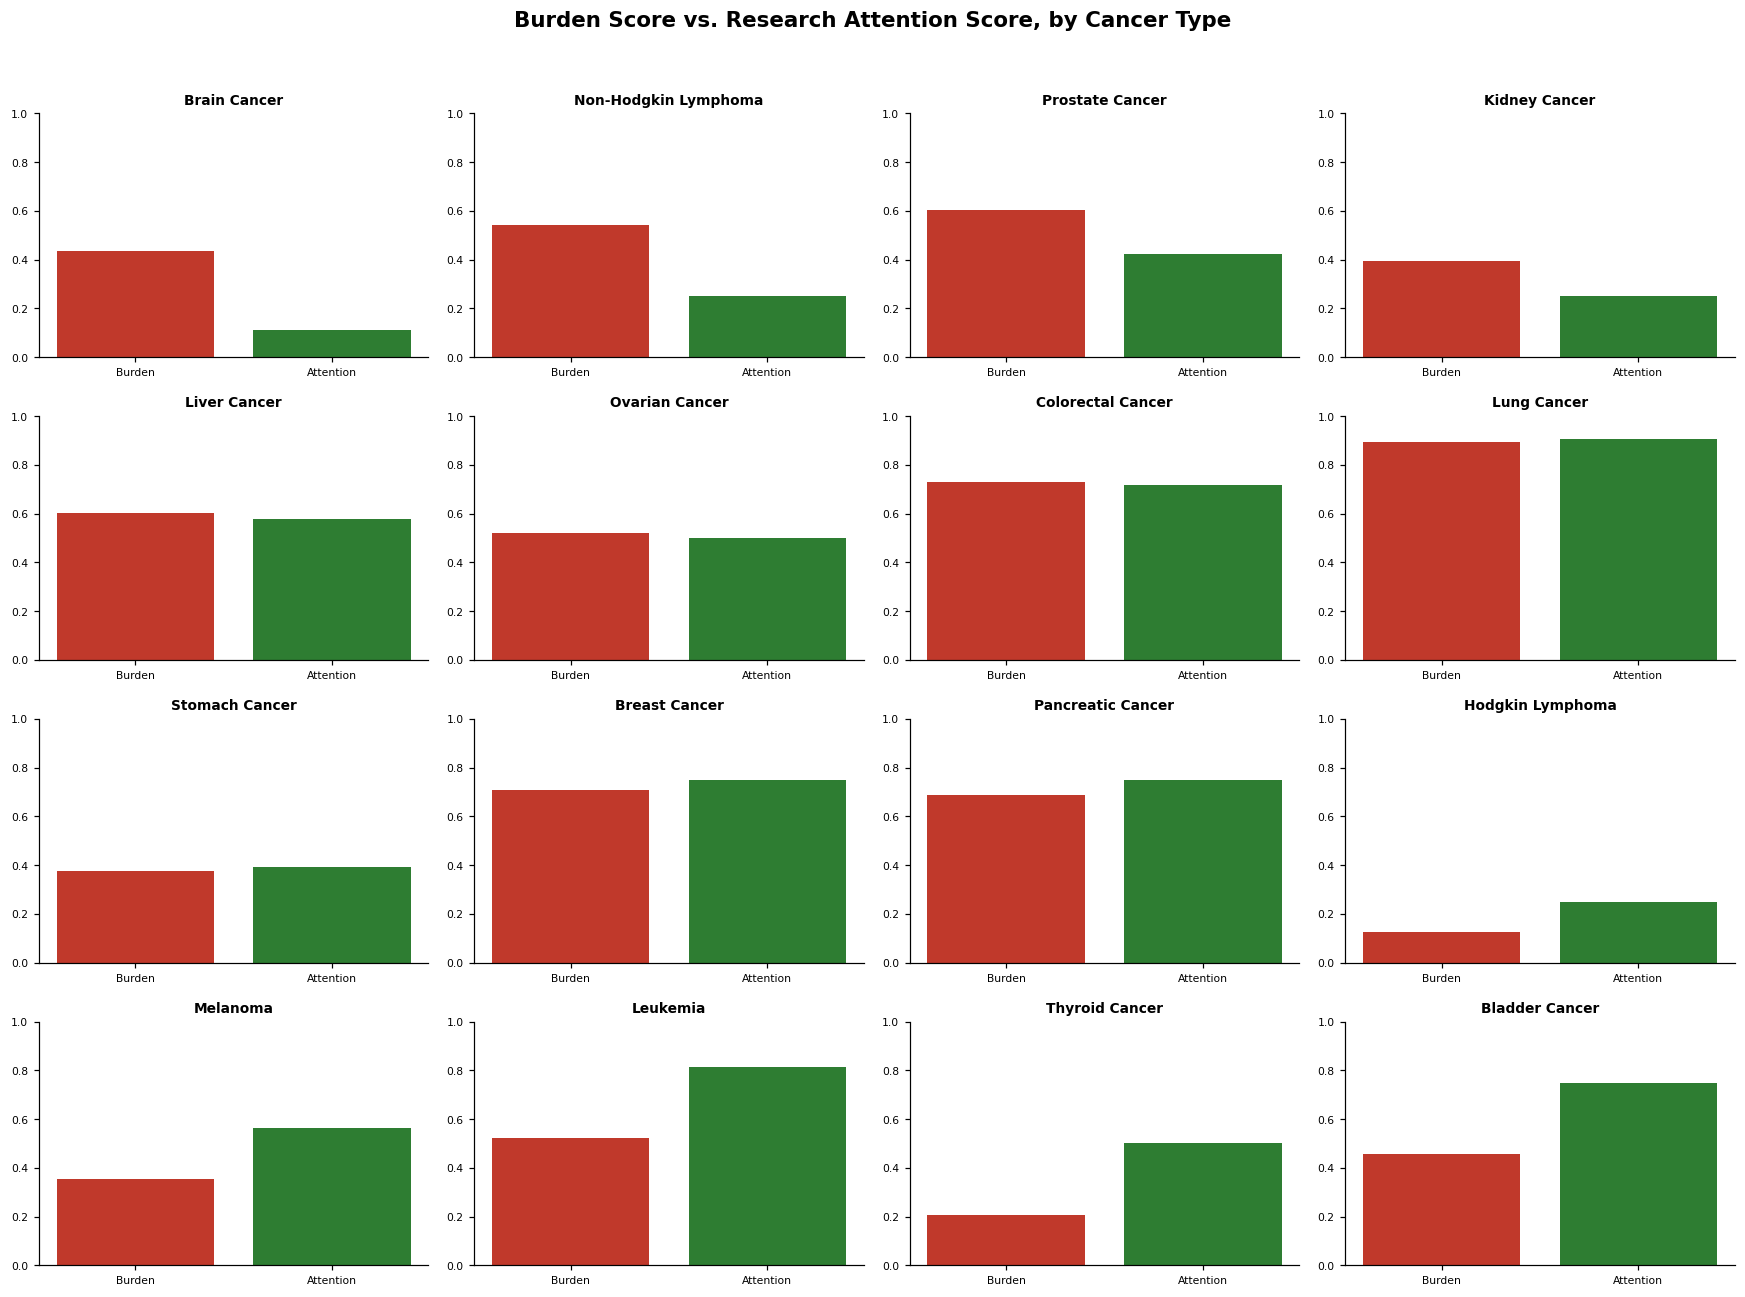

Saved: /content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts/14_advanced_small_multiples_panel.png


In [ ]:
# ============================================================
# Advanced Chart 3: Small-multiples panel (burden vs attention per cancer type)
# ============================================================

n = len(analysis_df)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

plot_order = analysis_df.sort_values("attention_gap_score", ascending=False).reset_index(drop=True)

for i, row in plot_order.iterrows():
    ax = axes[i]
    ax.bar(["Burden", "Attention"], [row["burden_score"], row["research_attention_score"]],
           color=["#C0392B", "#2E7D32"])
    ax.set_title(row["cancer_type"], fontsize=9)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=7)

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.suptitle("Burden Score vs. Research Attention Score, by Cancer Type", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

path = CHART_DIR / "14_advanced_small_multiples_panel.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


<p style="font-size:15px;"><b><u>13. Output Verification</u></b></p>

This section confirms that every processed dataset, table, and chart referenced in this notebook has
been saved to the correct project directory prior to submission.


In [ ]:
# ============================================================
# List all saved output files
# ============================================================

for label, folder in [("PROCESSED_DIR", PROCESSED_DIR), ("CHART_DIR", CHART_DIR), ("TABLE_DIR", TABLE_DIR)]:
    print(f"\n{label} ({folder}):")
    files = sorted(folder.glob("*"))
    if files:
        for f in files:
            print(" -", f.name)
    else:
        print(" (no files found)")



PROCESSED_DIR (/content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/01 Data/Processed Analysis Data):
 - analysis_ready_with_clusters.csv
 - cancer_attention_gap_analysis_base.csv
 - cancer_attention_gap_analysis_ready.csv

CHART_DIR (/content/drive/MyDrive/Applied ML II - Group 2/Cancer_Research_Attention_Gap_Final/04 Output Files/Charts):
 - 01_eda_key_variable_distributions.png
 - 02_ranked_attention_gap_score.png
 - 03_burden_vs_attention_scatter.png
 - 04_mortality_vs_publications.png
 - 05_mortality_vs_trials.png
 - 06_ratio_charts_publication_trial.png
 - 07_correlation_heatmap.png
 - 08_silhouette_scores_by_k.png
 - 09_cluster_profile_bars.png
 - 10_cluster_scatter_burden_vs_attention.png
 - 11_top_terms_under_attended_cancers.png
 - 12_advanced_bubble_chart.png
 - 13_advanced_dumbbell_rank_chart.png
 - 14_advanced_small_multiples_panel.png
 - component_level_attention_gap_comparison.png

TABLE_DIR (/content/drive/MyDrive/Applied ML II - Group 2/C

### Conclusion

This working notebook evaluates the composite Attention Gap Score, its incidence-, mortality-, and
survival-based component checks, a decision-maker review table, supporting visualizations,
clustering, and an exploratory NLP analysis. The final report focuses on the **composite Attention
Gap Score** as the primary metric, presented alongside the **component-level checks** to confirm
the finding is not an artifact of a single burden definition. Only the **selected visualizations**
identified in Section 10 (Final Analysis Direction) are carried into the final report.
**Clustering** is included only if the resulting profiles prove interpretable and add
decision-making value, and the **NLP/topic summary** is included only if it adds meaningful context
beyond the quantitative metrics. All other methods documented in this notebook — time-series
analysis, anomaly detection, PCA, and the incidence-based ratio checks — are retained here for
transparency and are not part of the final report.
